### PROJECT
### Student Course Completion Prediction

#### Problem Statement
##### This project aims to predict student course completion outcomes and identify the factors that influence learner persistence and dropout in online courses, enabling data-driven strategies to improve learner retention and course success.

#### Data collection
##### Data Source - https://www.kaggle.com/datasets/thedevastator/online-course-student-engagement-metrics

#### Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

#### Importing the dataset and displaying the first five rows

In [2]:
pd.set_option("display.max_columns", None)
file_path = r"C:\Users\HP\Downloads\raw.csv"
df = pd.read_csv(file_path)
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0


#### Understanding the dataset

In [3]:
# Printing the shape and columns of the dataset:

print(f"The shape of the dataset is {df.shape}.")
print()
print(f"The columns of the dataset are {df.columns}.")

The shape of the dataset is (641138, 21).

The columns of the dataset are Index(['index', 'course_id', 'userid_DI', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade',
       'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'roles', 'incomplete_flag'],
      dtype='object').


#### Checking the missing values in the columns

In [4]:
# We have to find the percentage of missing values in each column

(df.isnull().mean())*100

index                  0.000000
course_id              0.000000
userid_DI              0.000000
registered             0.000000
viewed                 0.000000
explored               0.000000
certified              0.000000
final_cc_cname_DI      0.000000
LoE_DI                16.534350
YoB                   15.067739
gender                13.539363
grade                  7.544710
start_time_DI          0.000000
last_event_DI         27.911932
nevents               31.062111
ndays_act             25.383459
nplay_video           71.362172
nchapters             40.358394
nforum_posts           0.000000
roles                100.000000
incomplete_flag       84.377622
dtype: float64

##### From the above cell, it is seen that the columns LoE_DI, YoB, gender, grade, last_event_DI, nevents, ndays_act, nplay_video, nchapters, roles, and incomplete flag have missing values. Out of these columns nplay_video, roles, and incomplete_flag have too many missing values (more than 50% values are missing). Imputing the columns with mean/median/mode would introduce bias in the dataset, so we have to drop these columns. The remaining columns need to be handled properly later.

#### Checking if the dataset has duplicates:

In [5]:
print(df.duplicated().sum())

0


##### The dataset has no duplicated rows.

#### Checking for the information on the dtypes of the columns:

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  object 
 2   userid_DI          641138 non-null  object 
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  object 
 8   LoE_DI             535130 non-null  object 
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  object 
 11  grade              592766 non-null  object 
 12  start_time_DI      641138 non-null  object 
 13  last_event_DI      462184 non-null  object 
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  np

##### The datatype of the column "start_time_DI" and "last_event_DI" are object, which needs to be converted into datetime and we can extract the year, month, and day out of those columns. The datatype of the grade column should be either int or float. We have to investigate the reason why it is object, take necessary actions and then change the dtype to either int or float.

##### Checking the number of unique values in each column of the dataset.

In [7]:
df.nunique()

index                641138
course_id                16
userid_DI            476532
registered                1
viewed                    2
explored                  2
certified                 2
final_cc_cname_DI        34
LoE_DI                    5
YoB                      78
gender                    3
grade                   104
start_time_DI           413
last_event_DI           404
nevents               10609
ndays_act               159
nplay_video            2728
nchapters                48
nforum_posts             14
roles                     0
incomplete_flag           1
dtype: int64

##### From the above information about the number of unique values, index has all unique values, so it can be dropped. But the "userid_DI" columns has some values repeated. This could be because a single student would have enrolled to multiple courses. This can be checked by:

In [8]:
df.groupby("userid_DI")["course_id"].count().sort_values(ascending = False)

userid_DI
MHxPC130505428    16
MHxPC130464954    16
MHxPC130232546    16
MHxPC130309858    16
MHxPC130183602    16
                  ..
MHxPC130597656     1
MHxPC130597659     1
MHxPC130597639     1
MHxPC130597646     1
MHxPC130597647     1
Name: course_id, Length: 476532, dtype: int64

##### We can see that some students have enrolled to more than one courses, so we can create a feature called "no_of_courses_enrolled" from this information and then drop the index column. We can also create a feature called "no_of_courses_explored" by each student, using the userid_DI and explored column.

##### Checking the statistical summary of the dataset.

In [9]:
df.describe()

,index,registered,viewed,explored,certified,YoB,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
count,641138.000000,641138.0,641138.000000,641138.000000,641138.000000,544533.000000,441987.000000,478395.000000,183608.000000,382385.000000,641138.000000,0.0,100161.0
mean,320568.500000,1.0,0.624299,0.061899,0.027587,1985.253279,431.008018,5.710254,114.844173,3.634423,0.018968,NaN,1.0
std,185080.742781,0.0,0.484304,0.240973,0.163786,8.891814,1516.116057,11.866471,426.996844,4.490987,0.229539,NaN,0.0
min,0.000000,1.0,0.000000,0.000000,0.000000,1931.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,1.0
25%,160284.250000,1.0,0.000000,0.000000,0.000000,1982.000000,3.000000,1.000000,5.000000,1.000000,0.000000,NaN,1.0
50%,320568.500000,1.0,1.000000,0.000000,0.000000,1988.000000,24.000000,2.000000,18.000000,2.000000,0.000000,NaN,1.0
75%,480852.750000,1.0,1.000000,0.000000,0.000000,1991.000000,158.000000,4.000000,73.000000,4.000000,0.000000,NaN,1.0
max,641137.000000,1.0,1.000000,1.000000,1.000000,2013.000000,197757.000000,205.000000,98517.000000,48.000000,20.000000,NaN,1.0


#### Insights from the statistical summary of the numerical columns
##### The mean and median of all the column "nevents" and "nplay_video" have a huge difference which indicates that there is significant skewness. But the column "nplay_video" has too many missing columns and can be dropped anyway. The exact skewness of the remaining columns has to be checked and handled properly later.

##### Checking the unique values in each column of the dataset:

In [10]:
for col in df.columns:
    print(f"The unique values of the {col} are {df[col].unique()}.")
    print()
    print()

The unique values of the index are [     0      1      2 ... 641135 641136 641137].


The unique values of the course_id are ['HarvardX/CB22x/2013_Spring' 'HarvardX/CS50x/2012'
 'HarvardX/ER22x/2013_Spring' 'HarvardX/PH207x/2012_Fall'
 'HarvardX/PH278x/2013_Spring' 'MITx/6.002x/2012_Fall'
 'MITx/6.002x/2013_Spring' 'MITx/14.73x/2013_Spring'
 'MITx/2.01x/2013_Spring' 'MITx/3.091x/2012_Fall'
 'MITx/3.091x/2013_Spring' 'MITx/6.00x/2012_Fall' 'MITx/6.00x/2013_Spring'
 'MITx/7.00x/2013_Spring' 'MITx/8.02x/2013_Spring'
 'MITx/8.MReV/2013_Summer'].


The unique values of the userid_DI are ['MHxPC130442623' 'MHxPC130275857' 'MHxPC130539455' ... 'MHxPC130184108'
 'MHxPC130359782' 'MHxPC130098513'].


The unique values of the registered are [1].


The unique values of the viewed are [0 1].


The unique values of the explored are [0 1].


The unique values of the certified are [0 1].


The unique values of the final_cc_cname_DI are ['United States' 'France' 'Unknown/Other' 'Mexico' 'Australia' 'I

##### The column "registered" has only one unique value, i.e., 1. So, it is not going to contribute to the model. Hence we can remove that. As stated earlier, the reason for the object dtype of the "grade" column is clear here. The column has an empty string which makes the dtype of the column object. We have to replace the empty string with NaN and convert the dtype of the column to float. But still handling the "grade" column may not be required. Because grade is calculated only after the person completed the course. So, it is a future metric. We cannot predict something using a future metric. It may cause data leakage. So, "grade" column needs to be dropped.

##### Feature Creation
##### We have the start_Year and YoB, from these two columns we can find the age of the student at the time of registering to the course and then drop the YoB column. We can also create features like course_duration by subtracting start_time_DI and last_event_DI. We can find the activity_ratio, number of events per active day using the columns "nevents" and "ndays_act", and number of chapters per active day also from "nchapters" and "ndays_act".

##### The new features are created and irrelevant features are dropped inside the Python scripts. We have to get the modified dataset here.

In [11]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [12]:
from src.data.loader import load_raw_data
from src.data_validation.validate_data import validate_data
from src.features.build_features import feature_engineering

data_path = os.path.join(PROJECT_ROOT, "data", "raw.csv")
df = load_raw_data(data_path)
df = validate_data(df)
df = feature_engineering(df)
pd.set_option("display.max_columns", None)
df.head()

Rows deleted due to invalid YoB: 455
Rows deleted due to invalid dates: 1443
Total rows deleted: 1898


,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,start_time_DI,last_event_DI,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,2012-12-19,2013-11-17,NaN,9.0,NaN,0,4,0
1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,2012-10-15,NaT,NaN,9.0,1.0,0,4,0
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,2013-02-08,2013-11-17,NaN,16.0,NaN,0,14,3
3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,2012-09-17,NaT,NaN,16.0,NaN,0,14,3
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,2012-12-19,NaT,NaN,16.0,NaN,0,14,3


In [13]:
BASE_DIR = Path.cwd().parent
MODEL_DIR = BASE_DIR/"saved_model"
from src.features.custom_transformers import FeatureEngineer

In [14]:
feature_engineer = FeatureEngineer()
df = feature_engineer.fit_transform(df)
df.head()

,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,9.0,NaN,0,4,0,2012,333.0,0.027027,NaN,0.000000,NaN,NaN
1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,9.0,1.0,0,4,0,2012,NaN,0.000000,NaN,0.000000,NaN,0.111111
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2013,282.0,0.056738,NaN,0.214286,NaN,NaN
3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN


In [15]:
# We have to separate the numerical and categorical columns which would help us in the EDA.

cat_cols = []
num_cols = []
for col in df.columns:
    if df[col].dtype == "O":
        cat_cols.append(col)
    else:
        num_cols.append(col)
print(cat_cols)
print(num_cols)

['course_id', 'userid_DI', 'final_cc_cname_DI', 'LoE_DI', 'gender']
['viewed', 'explored', 'certified', 'nevents', 'ndays_act', 'nchapters', 'nforum_posts', 'no_of_courses_registered', 'no_of_courses_explored', 'start_year', 'course_duration_days', 'activity_ratio', 'student_age_at_start', 'exploration_rate', 'avg_events_per_active_day', 'avg_chapters_per_active_day']


In [16]:
# In the above list, even though some columns are numerical, 
# they are categorical in nature. So we will move those columns to the categorical list. The columns are 'viewed',
# 'explored', and 'start_year'. The column 'certified' is the target column, so we will remove it from the numerical list,
# and keep it separate.
cat_cols.extend(['viewed', 'explored', 'start_year'])
num_cols.remove('viewed')
num_cols.remove('explored')
num_cols.remove('start_year')
num_cols.remove('certified')


print(len(cat_cols))
print(len(num_cols))
print(df.shape)

8
12
(639240, 21)


#### --------VISUAL EXPLORATION OF THE DATA----------
##### Univariate Analysis

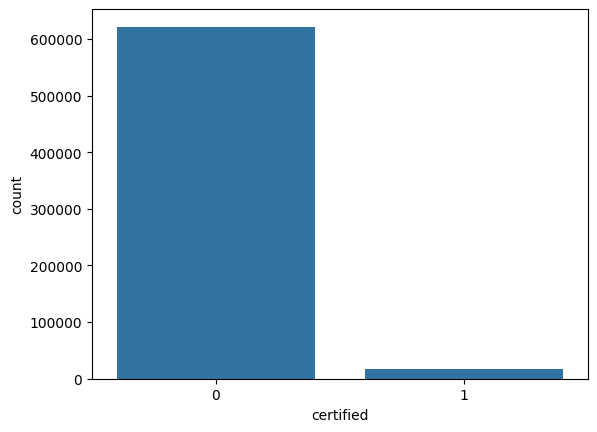

In [17]:
# Univariate analysis of the target column:

sns.countplot(x = "certified", data = df)
plt.show()

In [18]:
target_stats = df["certified"].value_counts()
target_stats

certified
0    621555
1     17685
Name: count, dtype: int64

##### Here, 0 represents the student has not completed the course and 1 represents the student has completed. The above plot shows that most of the students have not completed the course. The dataset is imbalanced, so we need to handle it later.

In [19]:
num_cols

['nevents',
 'ndays_act',
 'nchapters',
 'nforum_posts',
 'no_of_courses_registered',
 'no_of_courses_explored',
 'course_duration_days',
 'activity_ratio',
 'student_age_at_start',
 'exploration_rate',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day']

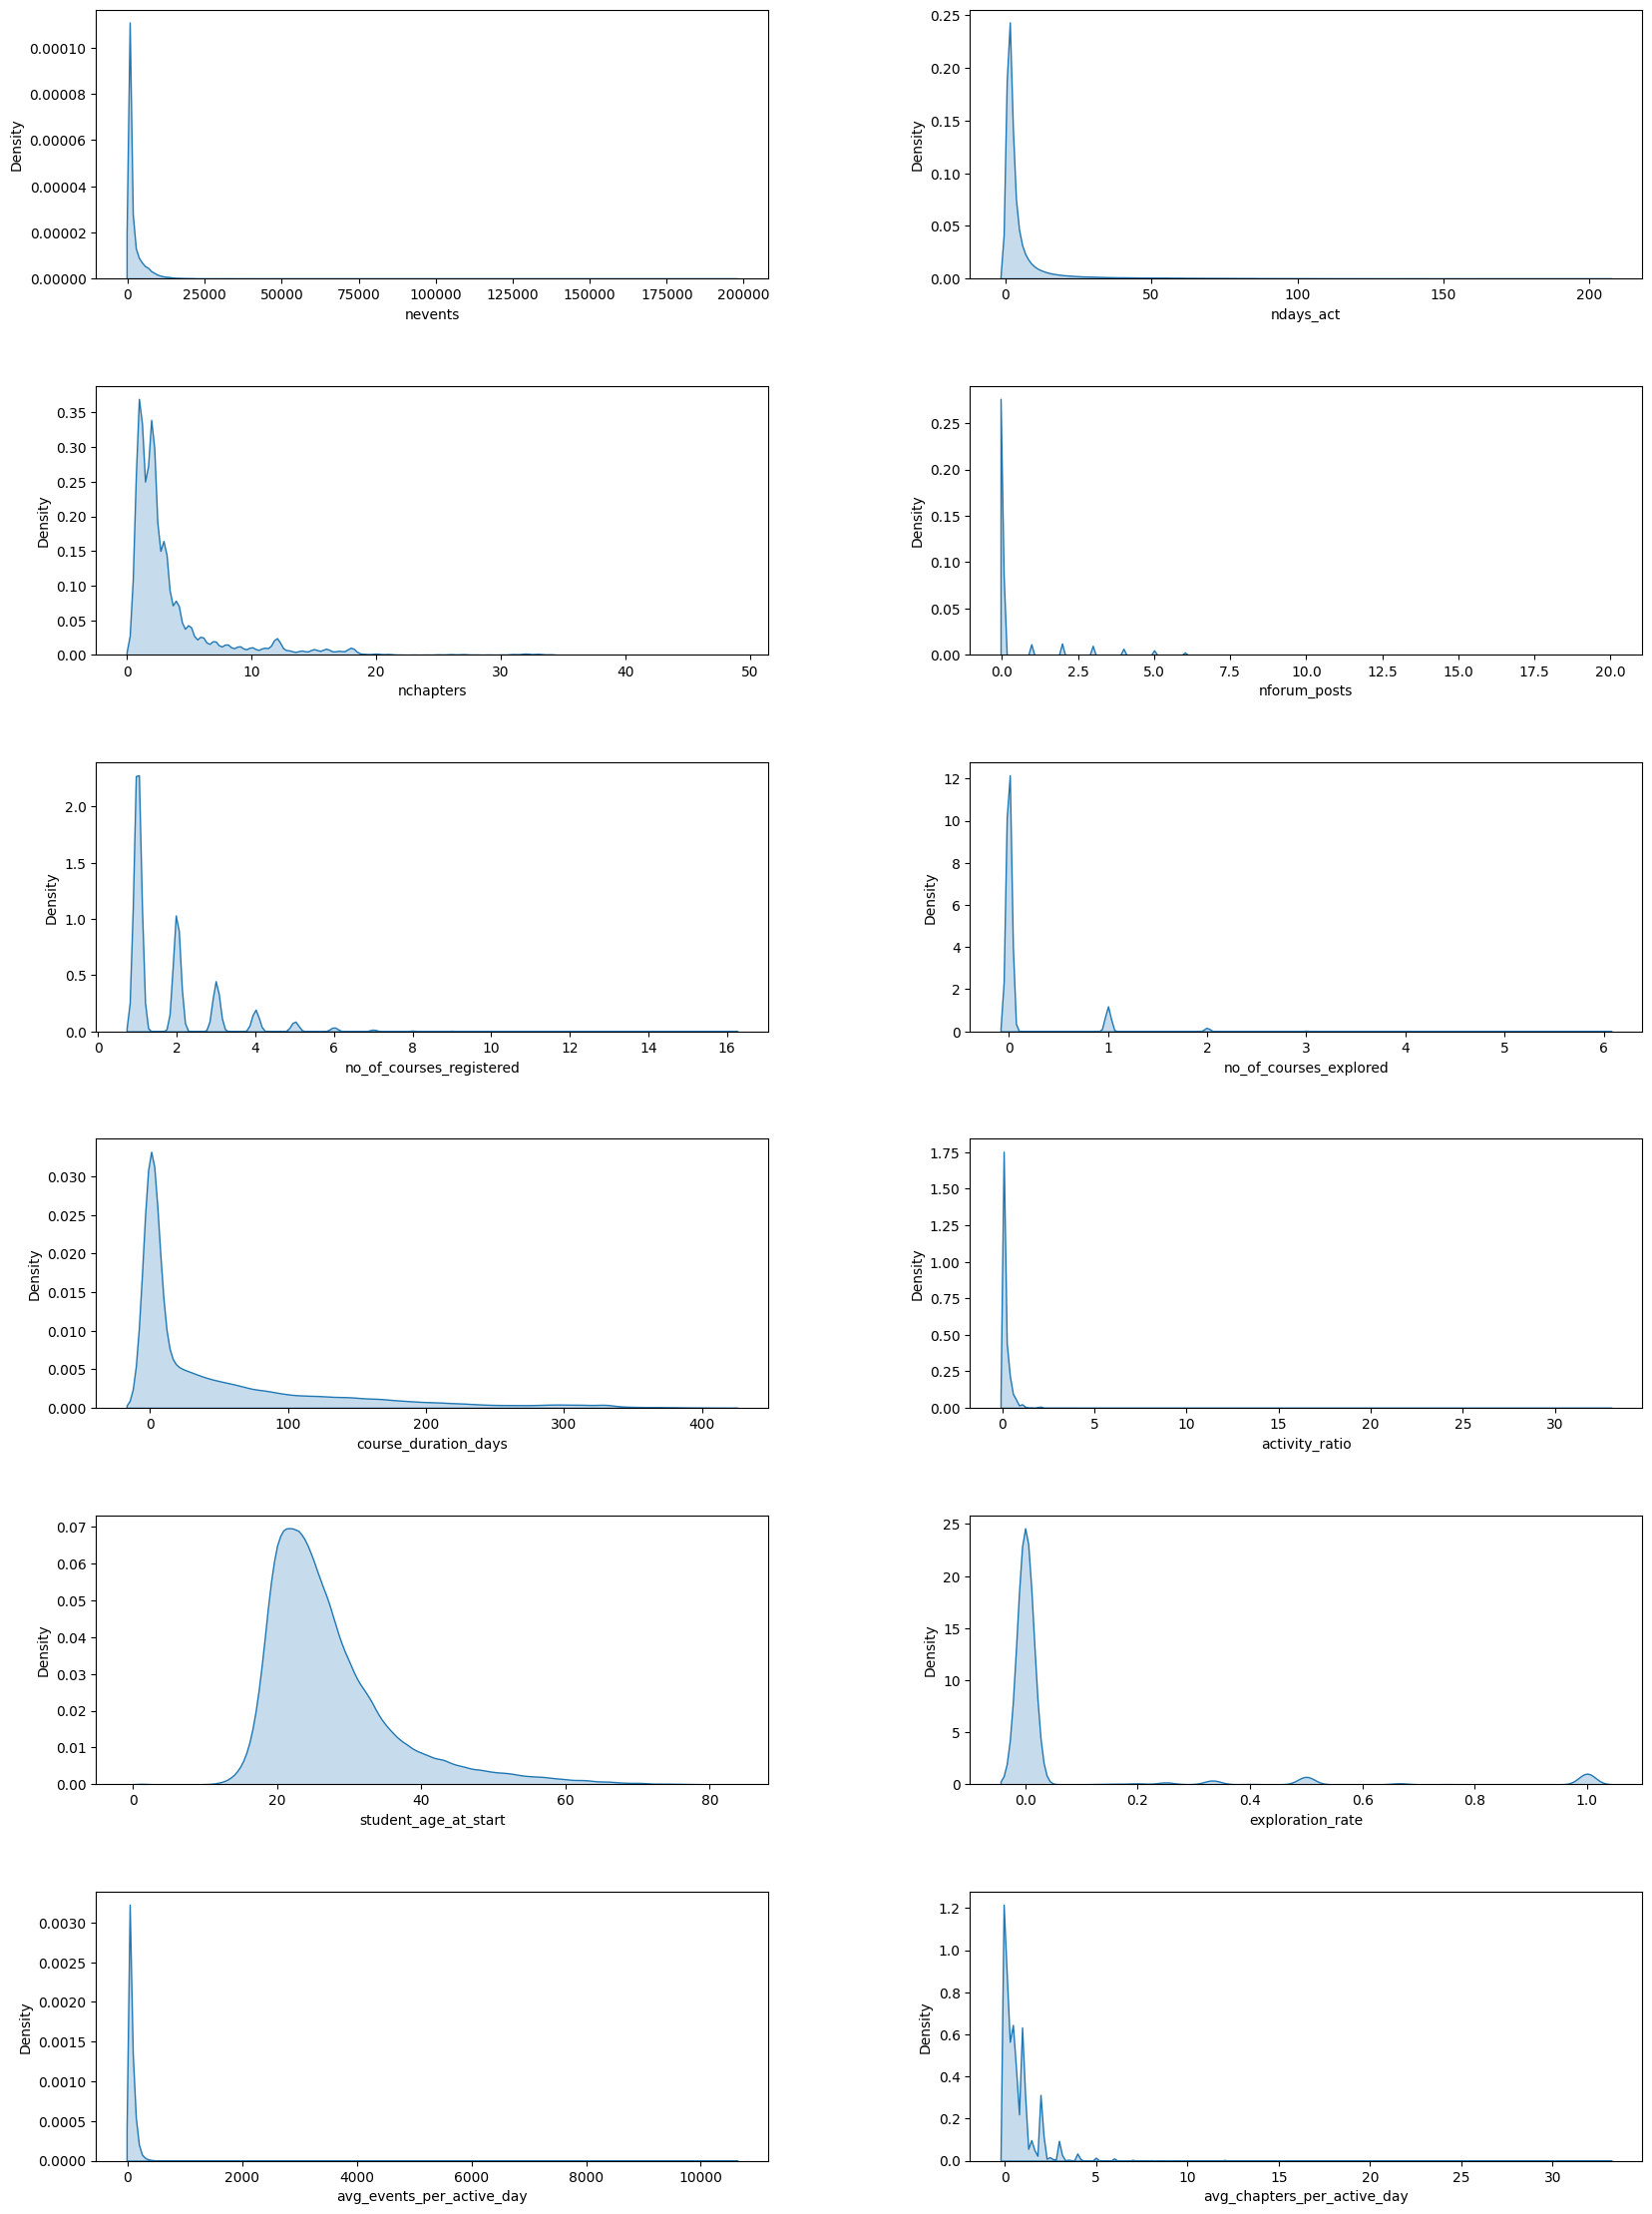

In [20]:
# Univariate analysis of numerical columns:

plt.close("all")
fig = plt.figure(figsize = (20, 28))
spec = fig.add_gridspec(6, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0,0])
sec_2 = fig.add_subplot(spec[0,1])
sec_3 = fig.add_subplot(spec[1,0])
sec_4 = fig.add_subplot(spec[1,1])
sec_5 = fig.add_subplot(spec[2,0])
sec_6 = fig.add_subplot(spec[2,1])
sec_7 = fig.add_subplot(spec[3,0])
sec_8 = fig.add_subplot(spec[3,1])
sec_9 = fig.add_subplot(spec[4,0])
sec_10 = fig.add_subplot(spec[4,1])
sec_11 = fig.add_subplot(spec[5,0])
sec_12 = fig.add_subplot(spec[5,1])
cnt = 0
sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6, sec_7, sec_8, sec_9, sec_10, sec_11, sec_12]
for col in num_cols:
    sns.kdeplot(x = col, ax = sec[cnt], fill = True, data = df)
    cnt += 1
plt.show()

In [21]:
# INSIGHTS FROM THE ABOVE GRAPHS

# 1) The number of events attended by the students is less than 25000, with most of the students having attended
# a small number of events around 0 (since there is a huge spike near 0). Students must be given more insights about
# the interactive events to increase their participation.

# 2) From the second graph, it seems many students have been active for less than 50 days, with
# most students being active for less than 10-20 days. The institute/company may send reminders or notifications to
# increase their activity.

# 3) The maximum number of chapters learnt by the students seem to be less than 20, with most students learning less
# than 5-10 chapters only. The institute/company may perform quality checks to see if the poor quality of the chapters'
# content is the reason for the low participation. If yes, the company may take steps to increase the quality of the content,
# so as to increase student engagement, hence the course completion and student retention in the company.

# 4) nforum_posts mean the discussion taking place through forum posts. From, the fourth graph, is is seen that
# there is a huge spkie near 0, meaning that most students do not participate in forum discussions. The institute/company
# may give insights to the students about the importance of forum discussions, and encourage them to participate more. This
# may increase the course completion rate.

# 5) The maximum value of course duration is less than 400 days, with most students having course duration less than
# 200 days.

# 6) The active_ratio of most of the students is close to 0, meaning that most students are inactive. The institute/company
# may send reminders or notifications to increase their activity.

# 7) Most of the students fall in the age group of 15-60, with a peak around 20-25.

# 8) The graph of number_of_courses_registered has many peaks, with the highest peak near 1, that means most of the students
# have registered for only 1 course. The second highest peak is near 2.

# 9) We can see 3 spikes in the number_of_courses_explored graph, with the highest spike near 0, meaning that
# most students do not explore many courses. The institute/company may give insights to the students about the importance
# of exploring more courses, and encourage them to do so. This may increase the course completion rate, and hence the
# retention of students in the company.

# 10) The graph of the exploration_rate again has few spikes, with the highest spike near 0, and two smaller spikes near
# 0.5 and 1. This means that most students have not explored the course properly. 

# 11) The avg_events_per_active_day graph has a huge spike around 0 to 50, meaning that most students attend 0 to 50 events
# on an average per active day.

# 12) From the avg_chapters_per_active day, it is seen that most of the students have studied less than 5 chapters
# on an average per active day.

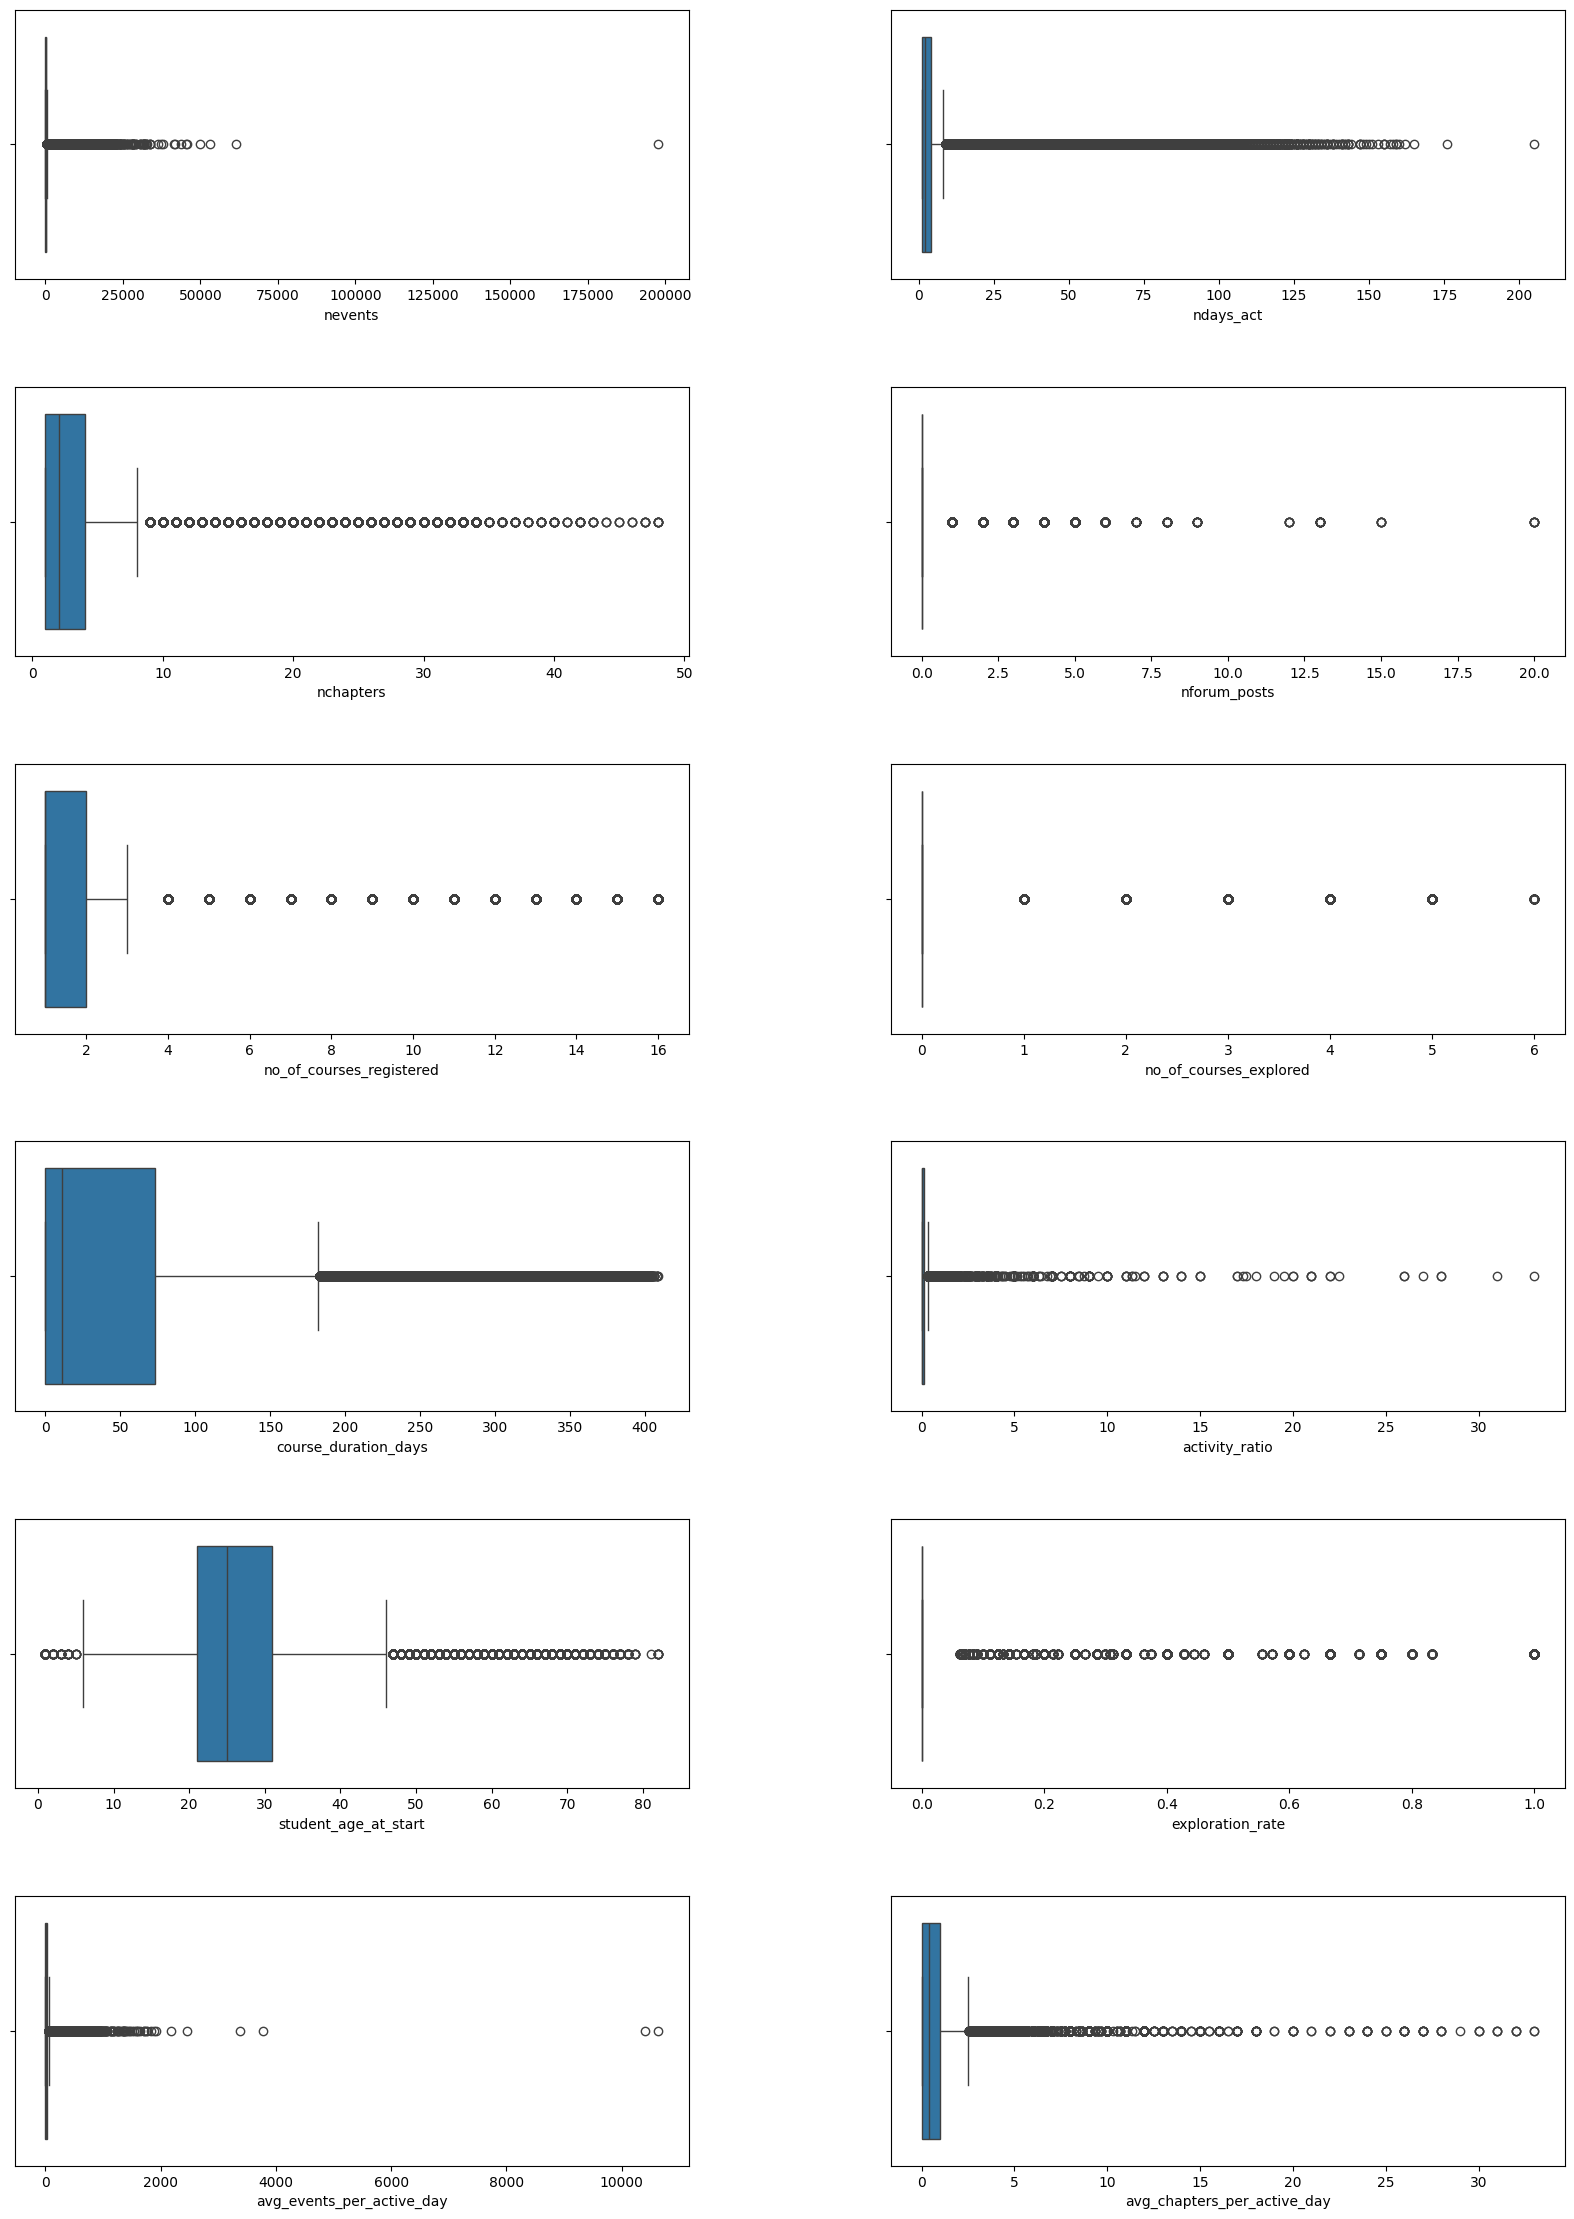

In [22]:
# Plotting boxplots of the above columns to see if outliers exist:

fig = plt.figure(figsize = (20, 28))
spec = fig.add_gridspec(6, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0,0])
sec_2 = fig.add_subplot(spec[0,1])
sec_3 = fig.add_subplot(spec[1,0])
sec_4 = fig.add_subplot(spec[1,1])
sec_5 = fig.add_subplot(spec[2,0])
sec_6 = fig.add_subplot(spec[2,1])
sec_7 = fig.add_subplot(spec[3,0])
sec_8 = fig.add_subplot(spec[3,1])
sec_9 = fig.add_subplot(spec[4,0])
sec_10 = fig.add_subplot(spec[4,1])
sec_11 = fig.add_subplot(spec[5,0])
sec_12 = fig.add_subplot(spec[5,1])
cnt = 0
sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6, sec_7, sec_8, sec_9, sec_10, sec_11, sec_12]
for col in num_cols:
    sns.boxplot(x = col, ax = sec[cnt], data = df)
    cnt += 1
plt.show()

##### Insights from the boxplots: All the columns have outliers which needs to be handled accordingly. Especially, the age column has values close to 0, which is not possible. So, we have to handle it carefully. We have to check if these columns have skewness too. If yes, we need to handle skewness too.

#### Bivariate Analysis of the categorical columns with respect to the target variable "certified":

In [23]:
cat_cols

['course_id',
 'userid_DI',
 'final_cc_cname_DI',
 'LoE_DI',
 'gender',
 'viewed',
 'explored',
 'start_year']

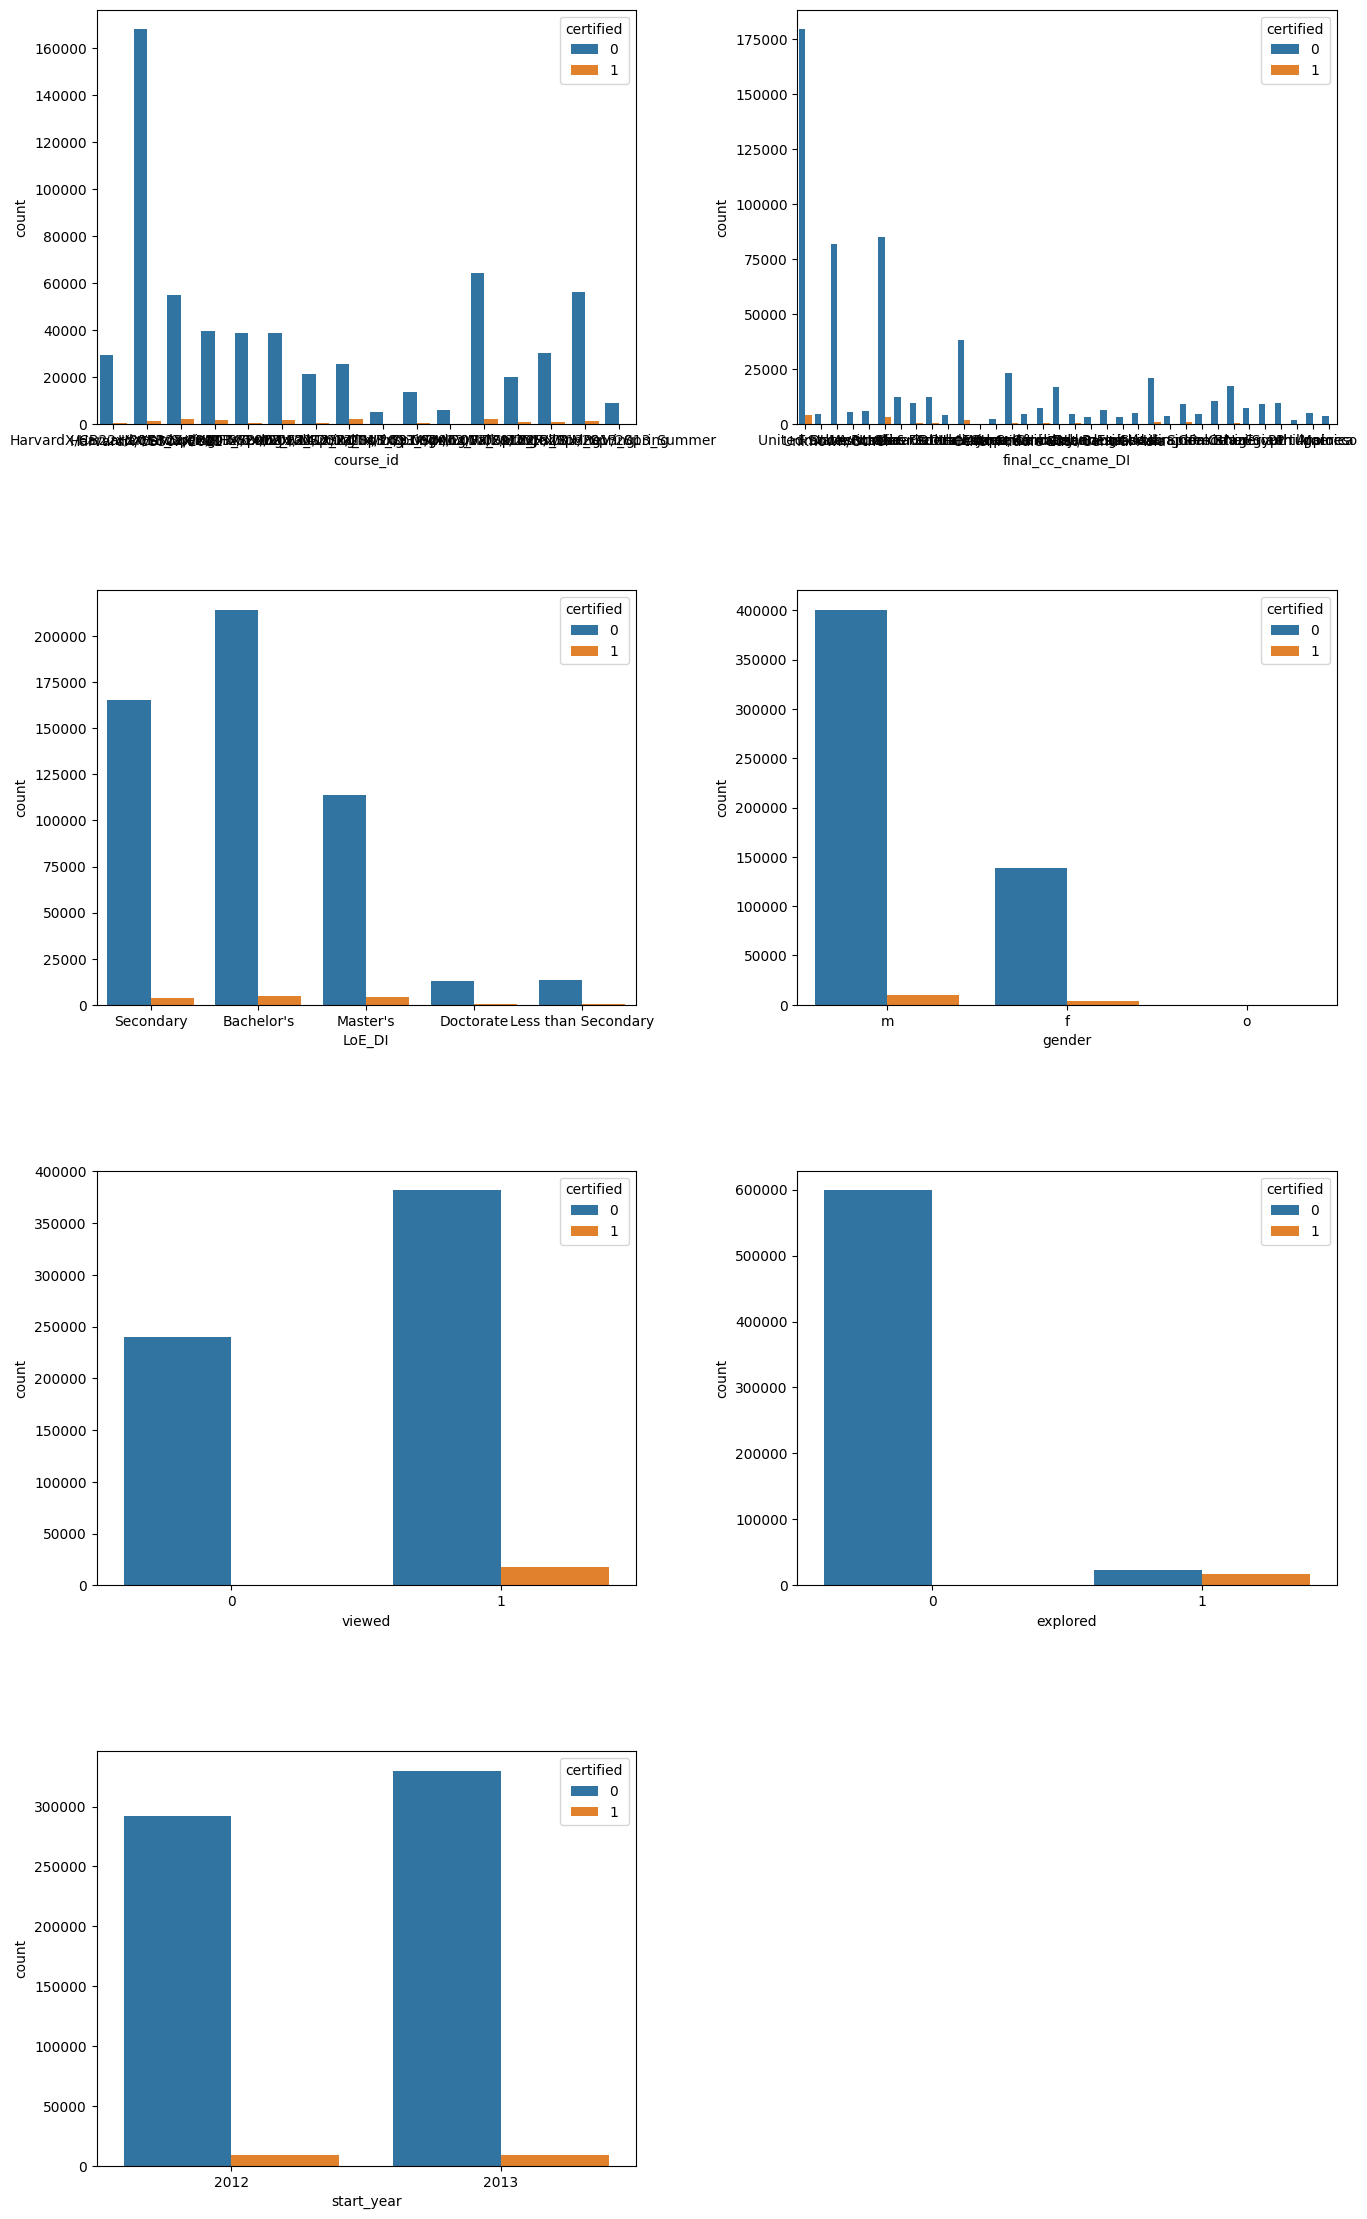

In [24]:
# Even though the column userid_DI is categorical in nature, it represents the personal IDs of the users,
# so we will not plot it.

fig = plt.figure(figsize = (16, 28))
spec = fig.add_gridspec(4, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0, 0])
sec_2 = fig.add_subplot(spec[0, 1])
sec_3 = fig.add_subplot(spec[1, 0])
sec_4 = fig.add_subplot(spec[1, 1])
sec_5 = fig.add_subplot(spec[2, 0])
sec_6 = fig.add_subplot(spec[2, 1])
sec_7 = fig.add_subplot(spec[3, 0])
cnt = 0
sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6, sec_7]
for col in cat_cols:
    if col != "userid_DI":
        sns.countplot(x = col, ax = sec[cnt], data = df, hue = "certified")
        cnt += 1
plt.show()

In [25]:
# 1) Countplot of viewed with hue = certified: We expected that the students who haven't viewed the course content would be more likely to not complete the couse.
# But apparently the students who have viewed the course have not completed the course. Only few students who have viewed the
# course content has completed the course. This could be because the course content was not so good or interesting. 
# The company may aim to increase the quality of the course content to improve the completion rate of the course.

# 2) Plot of explored with certified as hue: The students who have not explored the course are very less likely to complete the course.
# To make the students explore the course, the institute/company may send them reminder mails regarding the course.
# They may also keep an eye on the duration of the video content. If the video duration is too long, some students tend to
# skip them. The institute may make smaller to medium length of video contents to increase the student engagement and
# exploration.
# They may also simplify both text-based and video-based and make them interesting and engaging so that the
# students would explore the course content.

# 3) Most of the students registered for the courses have completed Bachelor's degree, but most of them have failed to complete
# the course. Again, here the institute may take steps to make the course content more interesting and send friendly 
# reminders to them to complete the course. To encorage course registeration across various educational levels, the insitute 
# may expand their courses to engage people among different educational levels.

# 4) Most of the students who have registered to the course are males. Female registeration is very less. The reason for this
# could be gender bias. The exact reason for this need to be further investigated and appropriate actions need to be taken. Some
# countries tend to educate male students more than the female students due to cultural or ideological values. Some people
# may even hesitate to spend money on females education. More investigaions need to be done to find if this is the reason.
# If yes, the institute/company may offer scholarships or discounts to encourage female registeration.

# 5) The years in which the courses have been started are 2012 and 2013. The course registeration in both these years are 
# more or less the same.

In [26]:
# The plots of the columns course_id and final_cc_cname_DI are not so clear. We can explore them without graphs
# by using groupby function. We can find the number of students who have completed each of the course.
ser1 = df.groupby("course_id")["certified"].sum()
ser2 = df.groupby("course_id")["certified"].count()
pd1 = pd.concat([ser1, ser2], axis = 1, keys = ["completed", "no_of_students_registered"])
pd1["Not_completed"] = pd1["no_of_students_registered"] - pd1["completed"]
pd1["Dropout_rate"] = (pd1["Not_completed"]/pd1["no_of_students_registered"])*100
pd1.sort_values(by = "Dropout_rate", ascending = False)

,completed,no_of_students_registered,Not_completed,Dropout_rate
course_id,,,,
HarvardX/CS50x/2012,1287,169075,167788,99.238799
HarvardX/CB22x/2013_Spring,384,29955,29571,98.718077
HarvardX/PH278x/2013_Spring,711,39553,38842,98.202412
MITx/6.00x/2013_Spring,1253,57464,56211,97.819504
MITx/3.091x/2013_Spring,138,6102,5964,97.738446
MITx/8.02x/2013_Spring,822,30929,30107,97.342300
MITx/6.002x/2013_Spring,593,22066,21473,97.312608
MITx/8.MReV/2013_Summer,297,9455,9158,96.858805
MITx/6.00x/2012_Fall,2477,66605,64128,96.281060


##### From the above dataframe, it is seen that most of the students registered to the course "HarvardX/CS50x/2012" have not completed the course. So, the institute/company may perform quality checks to see if the course quality is good. If not, they may take steps to increase the quality of the course content to make it interesting and insightful.The number of students registered for the course "MITx/2.01x/2013_Spring" is very less. The company may take steps to advertise about this course and increase its overall content quality to increase student registeration and engagement.

In [27]:
# Now checking the completed/not completed rate with respect to the final_cc_cname_DI column:

s1 = df.groupby("final_cc_cname_DI")["certified"].sum()
s2 = df.groupby("final_cc_cname_DI")["certified"].count()
d1 = pd.concat([s1, s2], axis = 1, keys = ["completed", "registered"])
d1["Not_completed"] = d1["registered"] - d1["completed"]
d1["Completion_rate"] = (d1["completed"]/d1["registered"])*100
d1["Dropout_rate"] = (d1["Not_completed"]/d1["registered"])*100
d1.sort_values(by = ["Dropout_rate", "registered"], ascending = [False, True])

,completed,registered,Not_completed,Completion_rate,Dropout_rate
final_cc_cname_DI,,,,,
Unknown/Other,61,81886,81825,0.074494,99.925506
Morocco,28,3952,3924,0.708502,99.291498
Bangladesh,34,3170,3136,1.072555,98.927445
China,62,5163,5101,1.200852,98.799148
Egypt,120,9262,9142,1.295616,98.704384
Pakistan,156,10793,10637,1.445381,98.554619
Other Oceania,5,345,340,1.449275,98.550725
Philippines,81,5369,5288,1.508661,98.491339
Japan,40,2268,2228,1.763668,98.236332


##### The dropout rate is high in almost all the columns, since the target variable "certified" is imbalanced. But the highest dropout rates is observed in Unknown/Other(places) and Morocco. The course registeration is the lowest in Other Oceania. Only 345 students from this region has registered to the course. The courses need to be advertised more into these regions to increase the student registeration in these regions and the student engagement can be increased by sending reminder emails and notifications in all the regions.

In [28]:
# Creating a dataframe to find the number of female students registered for the course in each region:

female_df = df[df["gender"] == "f"]
fem_ser = female_df.groupby("final_cc_cname_DI")["gender"].count().sort_values()
male_df = df[df["gender"] == "m"]
male_ser = male_df.groupby("final_cc_cname_DI")["gender"].count().sort_values()
ser = df["final_cc_cname_DI"].value_counts()
gender_df = pd.concat([ser, male_ser, fem_ser], axis = 1, keys = ["Total_registrations", "male_students", "female_students"])
gender_df["male_registration_rate"] = (gender_df["male_students"]/gender_df["Total_registrations"])*100
gender_df["female_registration_rate"] = (gender_df["female_students"]/gender_df["Total_registrations"])*100
gender_df.sort_values(by = "female_registration_rate", ascending = True)

,Total_registrations,male_students,female_students,male_registration_rate,female_registration_rate
final_cc_cname_DI,,,,,
Bangladesh,3170,2568,121,81.009464,3.817035
Morocco,3952,3581,197,90.612348,4.984818
Japan,2268,1235,226,54.453263,9.964727
Pakistan,10793,7445,1107,68.979894,10.256648
Other Oceania,345,151,42,43.768116,12.173913
Nigeria,7469,6207,945,83.103494,12.652296
Poland,5202,3316,666,63.744714,12.802768
Portugal,2190,1440,285,65.753425,13.013699
Mexico,5609,3632,746,64.753075,13.300053


In [29]:
# INSIGHTS FROM THE ABOVE DATAFRAME

# 1) It is seen that the female ragistration rate is low in comparison to the male registrations rate in all the countries,
# especially in countries like Bangladesh, Morocco, Nigeria, there is a huge gap between female registration rate and
# male registration rate. In almost all the countries, the female registration rate is less than 30% and it is half of
# that of the male registration rate. Proper steps may be taken to address this issue from both the institute/company side and
# government side. Scholarships or discounts may be offered to encourage female registrations.

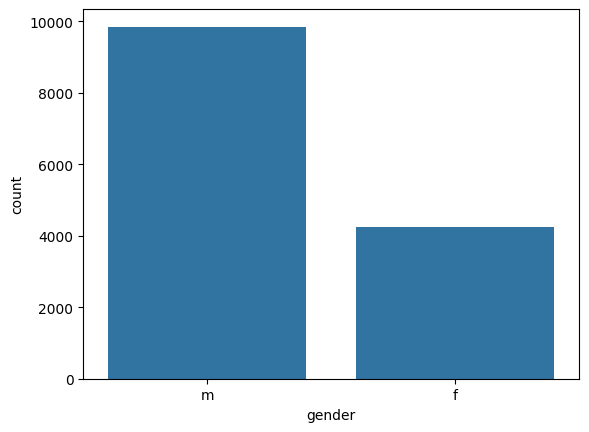

In [30]:
# Creating plots to understand which gender is most likely to complete the course:

completed_df = df[df["certified"] == 1]
sns.countplot(x = "gender", data = completed_df)
plt.show()

In [31]:
# From the above plot, it is seen that female students are less likely to complete the course. Less female registrations is 
# one of the reasons for this. Another reason could be gender bias. The institute/company may spreas awareness about the 
# education to girl students and encourage them to complete the course. 

In [32]:
# We have to find out the dropout rate for both genders from the course:

dropout_df = df[df["certified"] == 0]
drop_ser = dropout_df.groupby("gender")["certified"].count()
tot_ser = df["gender"].value_counts()
drop_rate_df = pd.concat([tot_ser, drop_ser], axis = 1, keys = ["total_registrations", "dropouts"])
drop_rate_df["dropout_rate"] = (drop_rate_df["dropouts"]/drop_rate_df["total_registrations"])*100
drop_rate_df.sort_values(by = "dropout_rate", ascending = False)

,total_registrations,dropouts,dropout_rate
gender,,,
o,17,17,100.000000
m,410215,400368,97.599551
f,142474,138242,97.029633


In [33]:
# INSIGHTS FROM THE ABOVE DATAFRAME
# The dropout rates are high for all students, male, female, and others, especially for others. The institute/company may take steps to reduce
# the dropouts by increase the quality of the course content, sending friendly reminders to the students, and making the
# course more interactive and engaging.

In [34]:
df.columns

Index(['course_id', 'userid_DI', 'viewed', 'explored', 'certified',
       'final_cc_cname_DI', 'LoE_DI', 'gender', 'nevents', 'ndays_act',
       'nchapters', 'nforum_posts', 'no_of_courses_registered',
       'no_of_courses_explored', 'start_year', 'course_duration_days',
       'activity_ratio', 'student_age_at_start', 'exploration_rate',
       'avg_events_per_active_day', 'avg_chapters_per_active_day'],
      dtype='object')

#### Bivariate Analysis of numerical columns with respect to the target variable

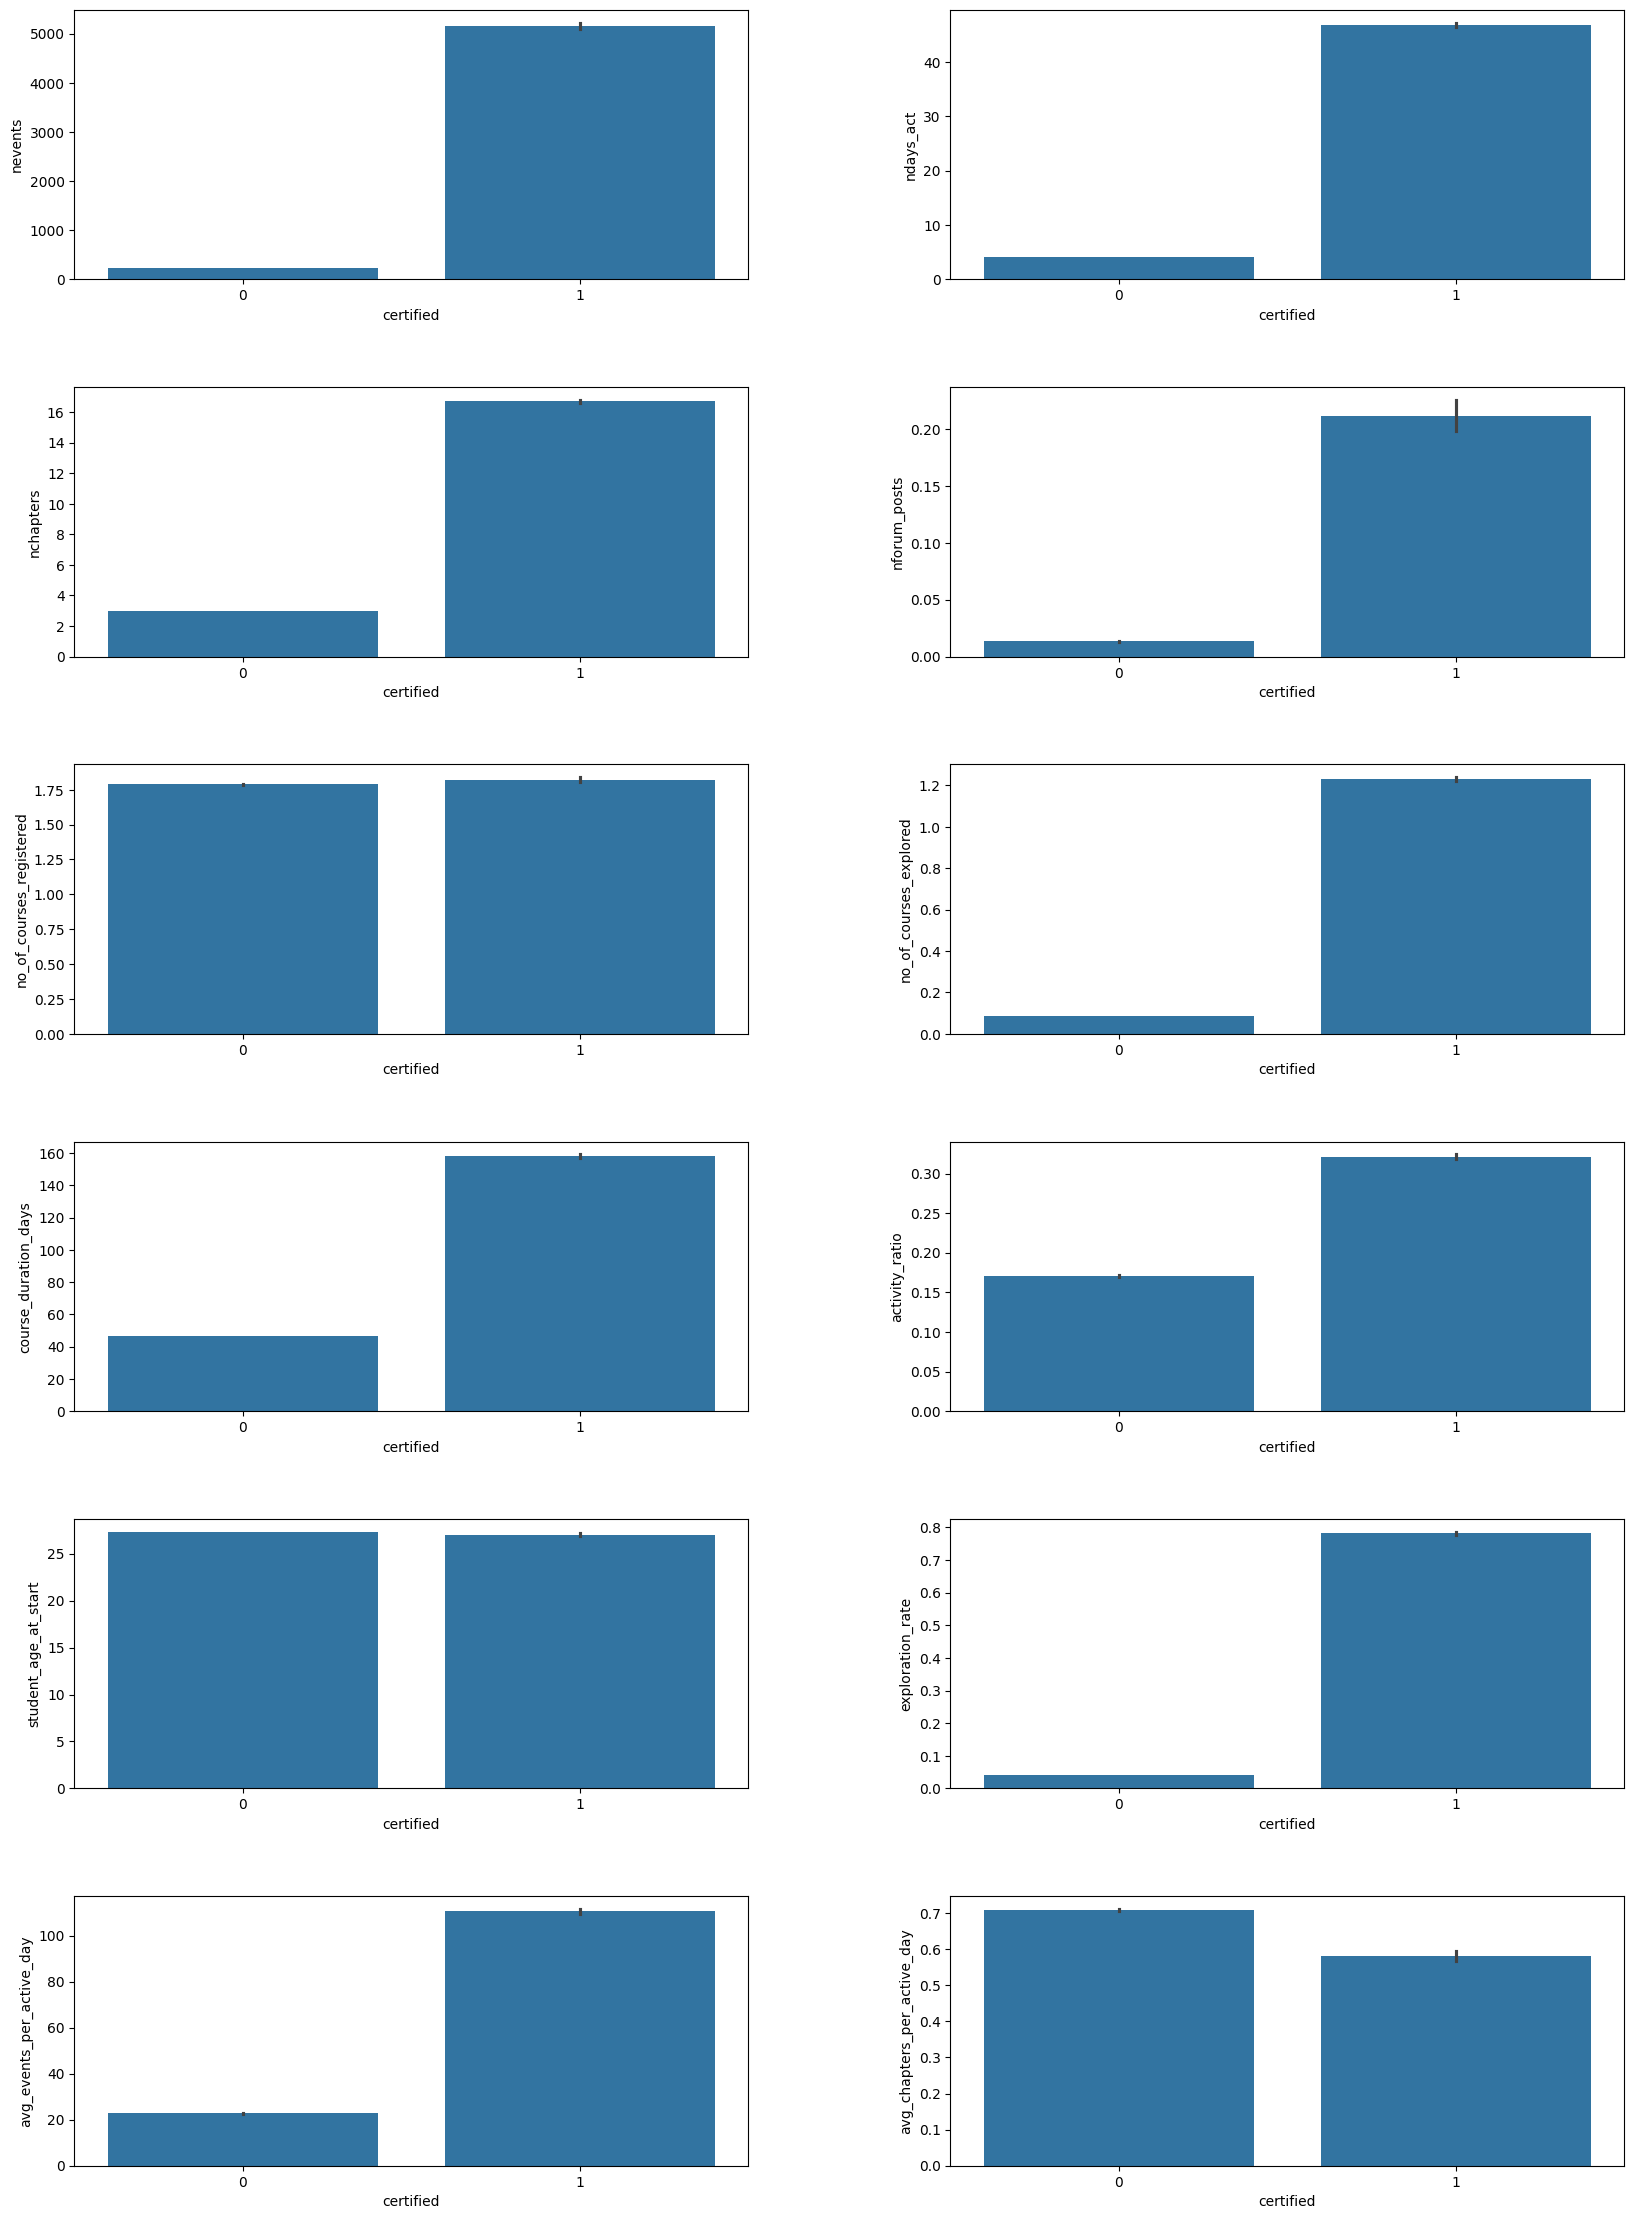

In [35]:
fig = plt.figure(figsize = (20, 28))
spec = fig.add_gridspec(6, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0,0])
sec_2 = fig.add_subplot(spec[0,1])
sec_3 = fig.add_subplot(spec[1,0])
sec_4 = fig.add_subplot(spec[1,1])
sec_5 = fig.add_subplot(spec[2,0])
sec_6 = fig.add_subplot(spec[2,1])
sec_7 = fig.add_subplot(spec[3,0])
sec_8 = fig.add_subplot(spec[3,1])
sec_9 = fig.add_subplot(spec[4,0])
sec_10 = fig.add_subplot(spec[4,1])
sec_11 = fig.add_subplot(spec[5,0])
sec_12 = fig.add_subplot(spec[5,1])
cnt = 0
sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6, sec_7, sec_8, sec_9, sec_10, sec_11, sec_12]
for col in num_cols:
    sns.barplot(x = "certified", y = col, ax = sec[cnt], data = df)
    cnt += 1
plt.show()

##### Insights from the above graphs:

In [36]:
# 1) The students who have attended more interactive events are more likely to complete the course. The institute/company may take actions to get the students involved in more
# interactive events, so that they develop interest to complete the course.

# 2) The students who have completed the course are active in the course for a longer time.

# 3) Those who have studies more number of chapters are more likely to complete the course. So, the institute/company may
# aim to increase the quality of the course content to encourage students to study more chapters.

# 4) The more the students participate in forum discussions, the more likely they are to complete the course. So, the 
# institute/company may give insights to the students about the importance of forum discussions, and encourage them to participate more.

# 5) The higher the course duration, the more likely the students are to complete the course.

# 6) The higher the active_ratio, the more likely the students are to complete the course.

# 7) From the graph, it seems that most students who have registered to the course are below 30 years of age. The number of 
# course completions and dropouts seem to be more or less the same across all age groups.

# 8) Regardless of whether the students have completed or not completed the course, most students have registered to maximum 
# of 2 courses. The course completion and dropout numbers are more or less the same across all number of courses registered.

# 9) The higher the number_of_courses_explored, the more likely the students are to complete the course. So, the institute/company
# may try to teach students about the importance of the course, ask opinions about the course content, and if they find 
# that the course quality is poor via students' feedback, they may take steps to increase the quality of the course content 
# to increase the course completion rate.

# 10) Similarly, higher the exploration_rate, the more likely the students are to complete the course.

# 11) The higher the students participate in interactive events per active day, the more likely they are to complete
# the course. This may be because of the clarity and insights they get from the interactive events. The institute/company
# may encourage the students to participate more in the interactive events.

# 12) The higher the chapters learnt per active day, the lesser the course completion. This may be because learning too much
# content in a single day may confuse the students. The institute/company may suggest the students to learn a moderate
# amount of content per active day, and be active on more days. This would help them to understand the content better, hence
# increasing the course completion rate.

In [37]:
df.head()

,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,9.0,NaN,0,4,0,2012,333.0,0.027027,NaN,0.000000,NaN,NaN
1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,9.0,1.0,0,4,0,2012,NaN,0.000000,NaN,0.000000,NaN,0.111111
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2013,282.0,0.056738,NaN,0.214286,NaN,NaN
3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN


In [38]:
# LOADING THE TRAINING AND TESTING DATASETS AFTER FEATURE ENGINEERING AND DATA VALIDATION:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
Y_train = pd.read_csv("../data/processed/Y_train.csv").squeeze()
Y_test = pd.read_csv("../data/processed/Y_test.csv").squeeze()

In [39]:
X_train.head()

,course_id,viewed,explored,final_cc_cname_DI,LoE_DI,YoB,gender,start_time_DI,last_event_DI,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored
0,HarvardX/CB22x/2013_Spring,0,0,United States,NaN,NaN,NaN,2012-12-19,2013-11-17,NaN,9.0,NaN,0,4,0
1,HarvardX/CS50x/2012,1,0,United States,NaN,NaN,NaN,2012-10-15,NaN,NaN,9.0,1.0,0,4,0
2,HarvardX/CB22x/2013_Spring,0,0,United States,NaN,NaN,NaN,2013-02-08,2013-11-17,NaN,16.0,NaN,0,14,3
3,HarvardX/CS50x/2012,0,0,United States,NaN,NaN,NaN,2012-09-17,NaN,NaN,16.0,NaN,0,14,3
4,HarvardX/ER22x/2013_Spring,0,0,United States,NaN,NaN,NaN,2012-12-19,NaN,NaN,16.0,NaN,0,14,3


In [40]:
X_train_EDA = X_train.copy()
X_test_EDA = X_test.copy()
Y_train_EDA = Y_train.copy()
Y_test_EDA = Y_test.copy()

In [41]:
X_train_EDA = feature_engineer.fit_transform(X_train_EDA)
X_train_EDA.head()

,course_id,viewed,explored,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day
0,HarvardX/CB22x/2013_Spring,0,0,United States,NaN,NaN,NaN,9.0,NaN,0,4,0,2012,333.0,0.027027,NaN,0.000000,NaN,NaN
1,HarvardX/CS50x/2012,1,0,United States,NaN,NaN,NaN,9.0,1.0,0,4,0,2012,NaN,0.000000,NaN,0.000000,NaN,0.111111
2,HarvardX/CB22x/2013_Spring,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2013,282.0,0.056738,NaN,0.214286,NaN,NaN
3,HarvardX/CS50x/2012,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN
4,HarvardX/ER22x/2013_Spring,0,0,United States,NaN,NaN,NaN,16.0,NaN,0,14,3,2012,NaN,0.000000,NaN,0.214286,NaN,NaN


In [42]:
# Finding the percentage of missing values in each column of X_train:

(X_train_EDA.isnull().mean())*100

course_id                       0.000000
viewed                          0.000000
explored                        0.000000
final_cc_cname_DI               0.000000
LoE_DI                         16.484927
gender                         13.502038
nevents                        31.066001
ndays_act                      25.401620
nchapters                      40.271347
nforum_posts                    0.000000
no_of_courses_registered        0.000000
no_of_courses_explored          0.000000
start_year                      0.000000
course_duration_days           27.921458
activity_ratio                  0.889433
student_age_at_start           15.022437
exploration_rate                0.000000
avg_events_per_active_day       5.664381
avg_chapters_per_active_day    24.827669
dtype: float64

In [43]:
# Separating the numerical columns which have missing values:

missing_num_cols = ["nevents", "ndays_act", "nchapters", "course_duration_days", "student_age_at_start", "avg_events_per_active_day", "avg_chapters_per_active_day"]
missing_num_cols.append("activity_ratio")

In [44]:
missing_num_cols

['nevents',
 'ndays_act',
 'nchapters',
 'course_duration_days',
 'student_age_at_start',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day',
 'activity_ratio']

In [45]:
# Separating the categorical columns which have missing values:

missing_cat_cols = ["LoE_DI", "gender"]
missing_cat_cols

['LoE_DI', 'gender']

In [46]:
# Separating all the numerical columns:

num_cols = missing_num_cols.copy()
num_cols.extend(["nforum_posts", "no_of_courses_registered", "no_of_courses_explored", "exploration_rate"])
num_cols

['nevents',
 'ndays_act',
 'nchapters',
 'course_duration_days',
 'student_age_at_start',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day',
 'activity_ratio',
 'nforum_posts',
 'no_of_courses_registered',
 'no_of_courses_explored',
 'exploration_rate']

In [47]:
# Separating all the categorical columns:

cat_cols = ["course_id", "final_cc_cname_DI", "viewed", "explored", "start_year", "LoE_DI", "gender"]

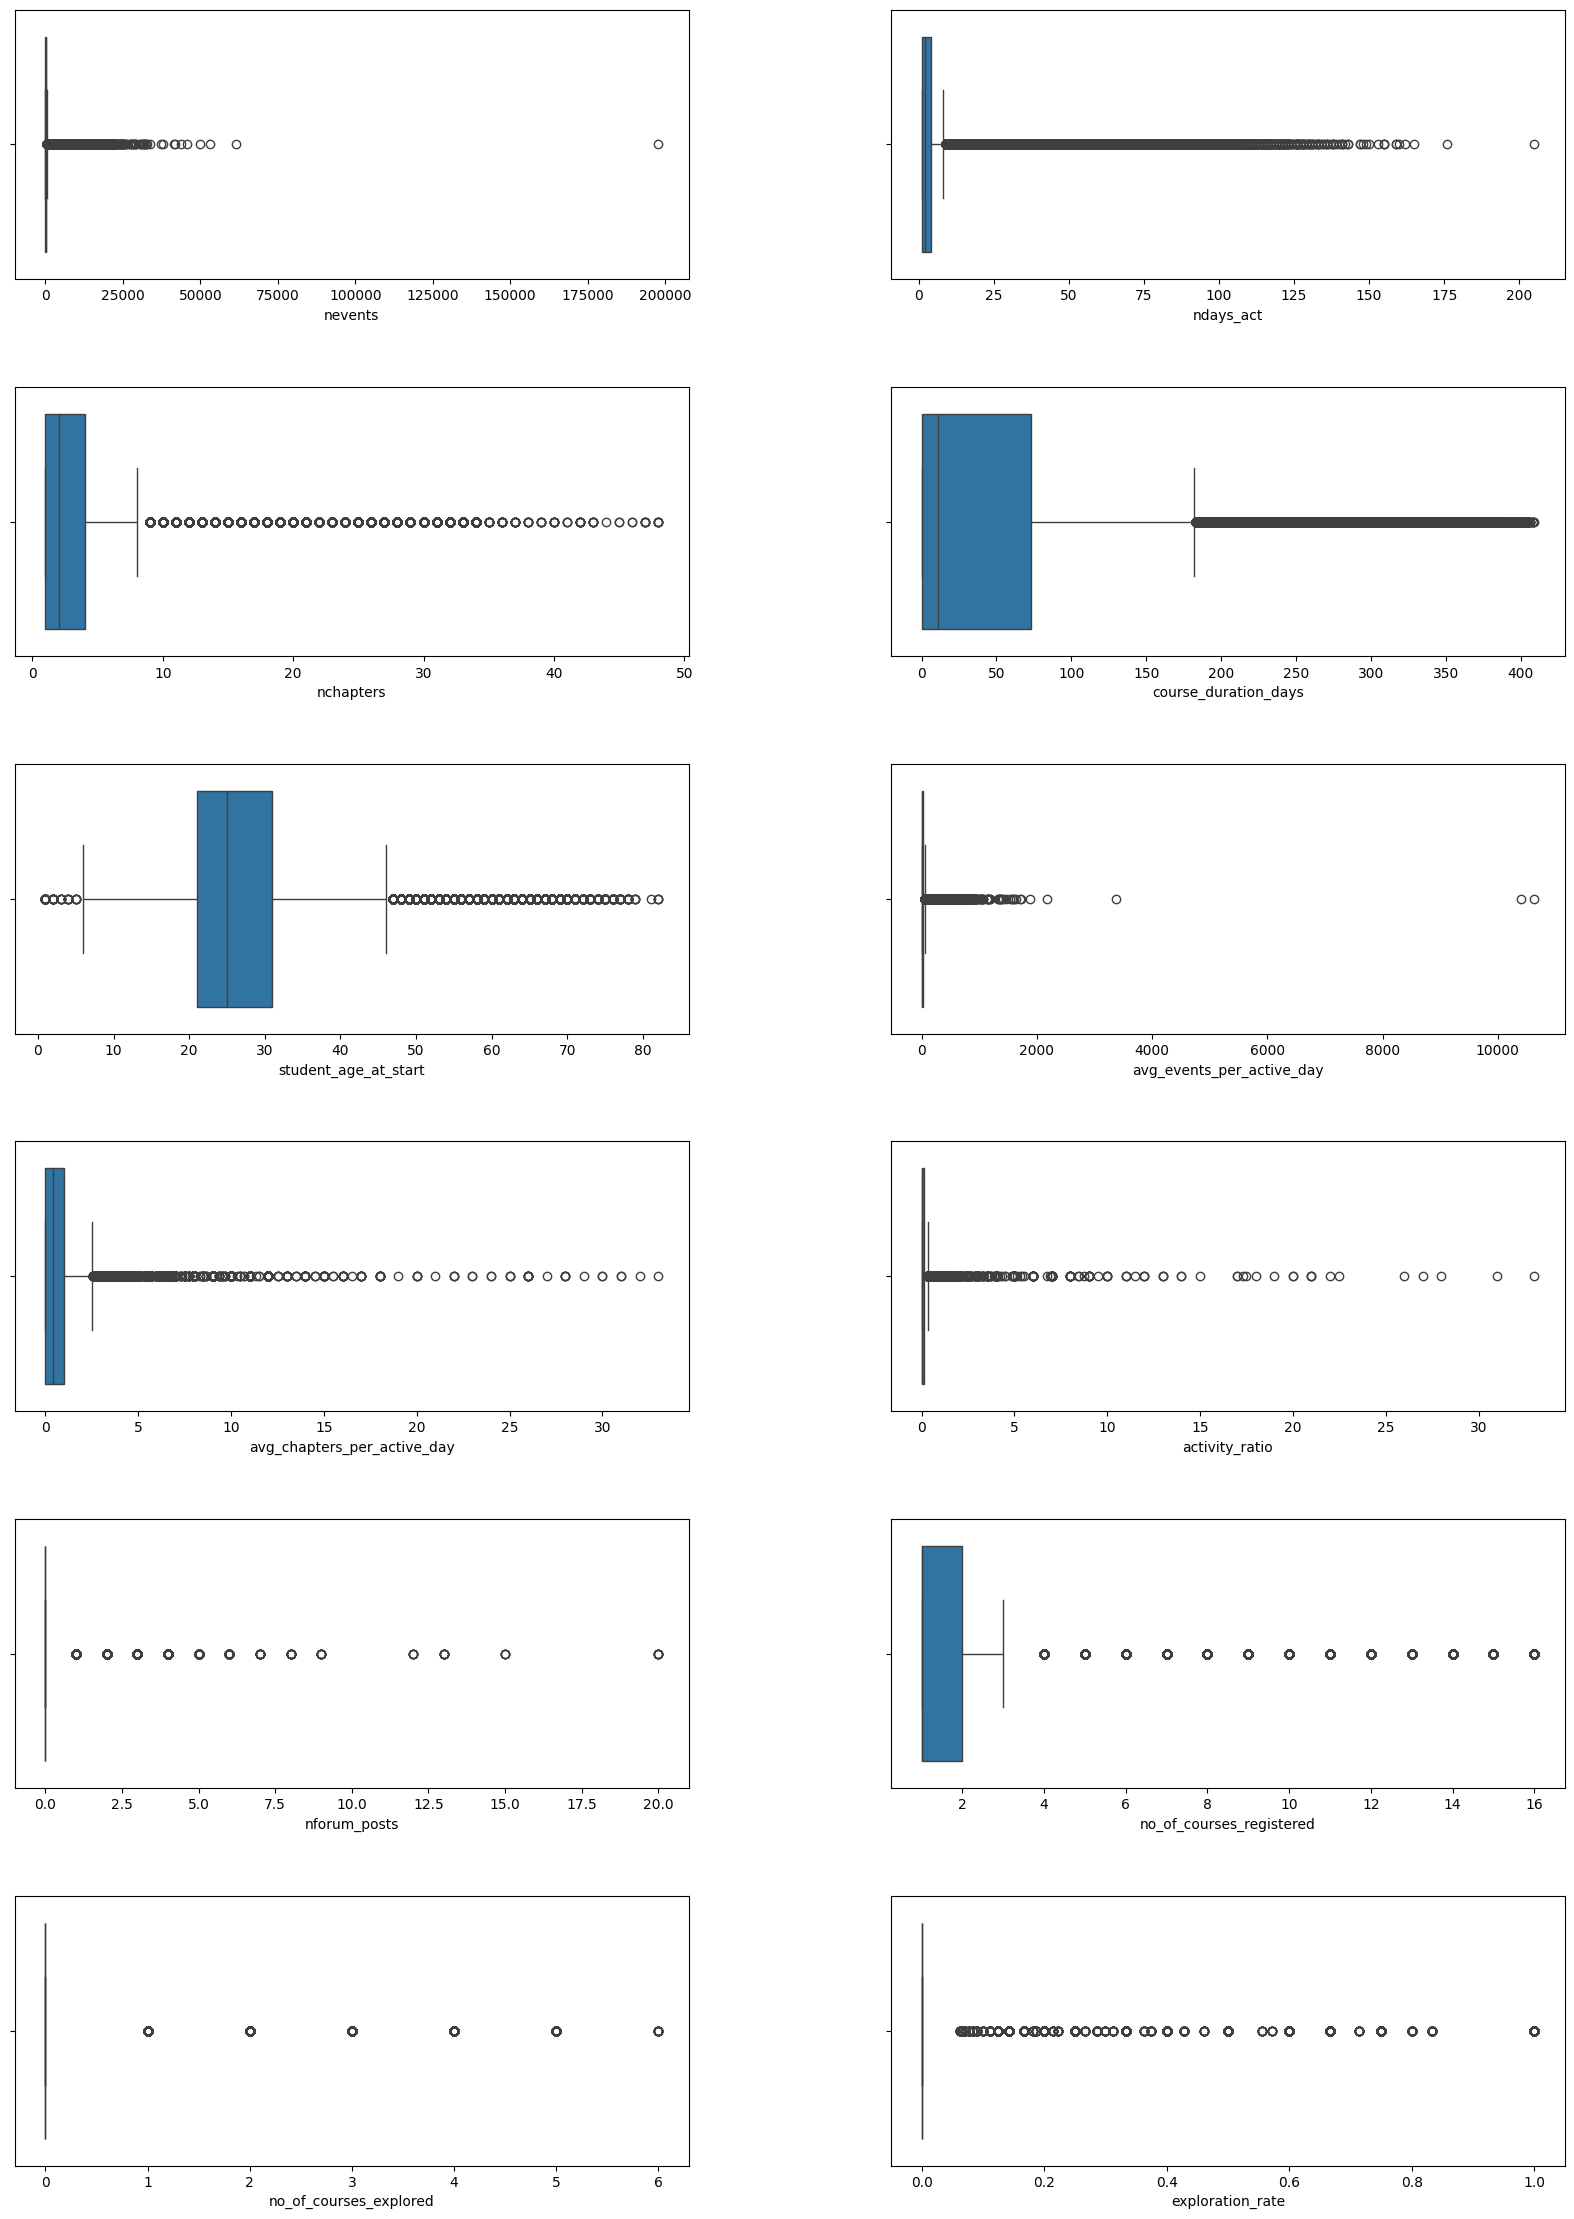

In [48]:
# CREATING BOXPLOTS TO CHECK FOR OUTLIERS IN THE NUMERICAL COLUMNS OF X_train:

plt.close("all")
fig = plt.figure(figsize = (20, 28))
spec = fig.add_gridspec(6, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0,0])
sec_2 = fig.add_subplot(spec[0,1])
sec_3 = fig.add_subplot(spec[1,0])
sec_4 = fig.add_subplot(spec[1,1])
sec_5 = fig.add_subplot(spec[2,0])
sec_6 = fig.add_subplot(spec[2,1])
sec_7 = fig.add_subplot(spec[3,0])
sec_8 = fig.add_subplot(spec[3,1])
sec_9 = fig.add_subplot(spec[4,0])
sec_10 = fig.add_subplot(spec[4,1])
sec_11 = fig.add_subplot(spec[5,0])
sec_12 = fig.add_subplot(spec[5,1])
cnt = 0
sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6, sec_7, sec_8, sec_9, sec_10, sec_11, sec_12]
for col in num_cols:
    sns.boxplot(x = col, ax = sec[cnt], data = X_train_EDA)
    cnt += 1
plt.show()

In [49]:

# All numerical columns of the dataset has outliers, so we have to fill the missing values using median imputation.
for col in missing_num_cols:
    median = X_train_EDA[col].median()
    X_train_EDA[col].fillna(median, inplace = True)

In [50]:
# The missing values in the categorical columns can be filled using mode imputation.
for col in missing_cat_cols:
    mode = X_train_EDA[col].mode()[0]
    X_train_EDA[col].fillna(mode, inplace = True)

In [51]:
X_train_EDA.isnull().sum()

course_id                      0
viewed                         0
explored                       0
final_cc_cname_DI              0
LoE_DI                         0
gender                         0
nevents                        0
ndays_act                      0
nchapters                      0
nforum_posts                   0
no_of_courses_registered       0
no_of_courses_explored         0
start_year                     0
course_duration_days           0
activity_ratio                 0
student_age_at_start           0
exploration_rate               0
avg_events_per_active_day      0
avg_chapters_per_active_day    0
dtype: int64

In [52]:
# Creating a function to detect the outliers in each numerical column using the IQR method and the skewness:
from scipy.stats import skew
def detect_outliers(num_cols):
    for col in num_cols:
        Q1 = X_train_EDA[col].quantile(0.25)
        Q3 = X_train_EDA[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        max_val = X_train_EDA[col].max()
        min_val = X_train_EDA[col].min()
        highest_limit = X_train_EDA[col].quantile(0.99)
        lowest_limit = X_train_EDA[col].quantile(0.01)
        outliers_percent = (X_train_EDA[(X_train_EDA[col] < lower_bound) | (X_train_EDA[col] > upper_bound)].shape[0]/X_train_EDA.shape[0])*100
        outlier_rows = X_train_EDA[(X_train_EDA[col] < lower_bound) | (X_train_EDA[col] > upper_bound)].shape[0]
        print(f"Outlier percentage of the column {col} is {outliers_percent} %.")
        print(f"Number of outlier rows in the column {col} is {outlier_rows}.")
        print(f"Minimum value is {min_val}.")
        print(f"Lower limit is {lower_bound}.")
        print(f"Maximum value is {max_val}.")
        print(f"Upper limit is {upper_bound}.")
        print(f"99th percentile value is {highest_limit}.")
        print(f"1st percentile value is {lowest_limit}.")
        print(f"The number of rows above the 99th percentile is {X_train_EDA[X_train_EDA[col] > highest_limit].shape[0]}.")
        print(f"The number of rows below the 1st percentile is {X_train_EDA[X_train_EDA[col] < lowest_limit].shape[0]}.")
        print(f"Skewness of the column is {skew(X_train_EDA[col])}.")
        print()
        print()

In [53]:
detect_outliers(num_cols)

Outlier percentage of the column nevents is 17.44657921390897 %.
Number of outlier rows in the column nevents is 78030.
Minimum value is 1.0.
Lower limit is -78.0.
Maximum value is 197757.0.
Upper limit is 154.0.
99th percentile value is 6675.0.
1st percentile value is 1.0.
The number of rows above the 99th percentile is 4473.
The number of rows below the 1st percentile is 0.
Skewness of the column is 16.002632049141553.


Outlier percentage of the column ndays_act is 13.448376862209363 %.
Number of outlier rows in the column ndays_act is 60148.
Minimum value is 1.0.
Lower limit is -2.0.
Maximum value is 205.0.
Upper limit is 6.0.
99th percentile value is 59.0.
1st percentile value is 1.0.
The number of rows above the 99th percentile is 4429.
The number of rows below the 1st percentile is 0.
Skewness of the column is 5.502071036941655.


Outlier percentage of the column nchapters is 42.522878652032084 %.
Number of outlier rows in the column nchapters is 190184.
Minimum value is 1.0.
Lo

In [54]:
# COLUMN: nevents:
# The outliers can be capped using the 99th percentile value. And a column named "nevents_outlier" can be created to indicate
# the rows which are above the upper limit.

# COLUMN: ndays_act:
# The maximum value of the column is 205, which seems to be a valid value. So, let's not cap the outliers in the column for now.
# We will create a column named "ndays_act_outlier" to indicate the outlier rows (rows above the upper limit.

# COLUMN: nchapters:
# This column had too many missing values (around 40%) and too many outliers too (around 42%). But the maximum value is 48,
# which seems to be a valid value. So, let's keep the outliers for now and create an outlier indicator column (to
# indicate rows above and see how the model performs. 
# If required, we will either cap the outliers or drop this column later.

# COLUMN: course_duration_days: The outliers in the column seems to be valid, so let's only create an outlier indicator
# column and see how the model performs.

# COLUMN: student_age_at_start:
# The minimum value of this column seems to be impossible, so we can cap it with the lower limit. The maximum value
# has a 50-50 chance of being possible. So, we will better cap it with the 99th quantile value. Outlier indicator is
# not mandatory here, because we are already capping it with the lower limit.

# COLUMN: avg_events_per_active_day: The minimum value seems to be valid. No need of capping. The maximum value seems to be
# too much, and is an outlier. It can be capped with the upper limit. The 99th percentile also seems to be too big a value.

# COLUMN: avg_chapters_per_active_day: The minimum value is valid, and the maximum value can be capped with the 
# 99th percentile value. An outlier indicator can also be created.

# COLUMN: activity_ratio: The minimum value is valid, and the maximum value can be capped with the 99th percentile value. 
# An outlier indicator can also be created.

# COLUMN: nforum_posts: The minimum value is valid, no capping needed. The maximum value also seems to be valid. So, we can
# cap the outliers with the the quantile value of 0.995, and create a binary indicator.

# COLUMN: no_of_courses_registered: The minimum value is valid, no capping needed. The maximum value van be capped with
# the 99th percentile, and a binary indicator to indicate the outliers can be created.

# COLUMN: no_of_courses_explored: The minimum value is valid, no capping needed. The maximum value van be capped with
# the 99th percentile, and a binary indicator to indicate the outliers can be created.

# COLUMN: exploration_rate: The minimum and the maximum values both are valid. No treatment needed here.

In [55]:
# Handling Outliers in the column "nevents":

Q1 = X_train_EDA["nevents"].quantile(0.25)
Q3 = X_train_EDA["nevents"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_nevents = Q1 - 1.5 * IQR
upper_bound_nevents = Q3 + 1.5 * IQR
highest_limit_nevents = X_train_EDA["nevents"].quantile(0.99)
lowest_limit_nevents = X_train_EDA["nevents"].quantile(0.01)
X_train_EDA["nevents"] = X_train_EDA["nevents"].clip(upper = highest_limit_nevents)

In [56]:
X_train_EDA["nevents_outliers"] = (X_train_EDA["nevents"] > upper_bound_nevents).astype(int)

In [57]:
# Handling outliers in the column "ndays_act"

Q1 = X_train_EDA["ndays_act"].quantile(0.25)
Q3 = X_train_EDA["ndays_act"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_ndays_act = Q1 - 1.5 * IQR
upper_bound_ndays_act = Q3 + 1.5 * IQR
X_train_EDA["ndays_act_outliers"] = (X_train_EDA["ndays_act"] > upper_bound_ndays_act).astype(int)

In [58]:
# Handling nchapters

Q1 = X_train_EDA["nchapters"].quantile(0.25)
Q3 = X_train_EDA["nchapters"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_nchapters = Q1 - 1.5 * IQR
upper_bound_nchapters = Q3 + 1.5 * IQR
X_train_EDA["nchapters_outliers"] = (X_train_EDA["nchapters"] > upper_bound_nchapters).astype(int)

In [59]:
# Handling course_duration_days

Q1 = X_train_EDA["course_duration_days"].quantile(0.25)
Q3 = X_train_EDA["course_duration_days"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_course_duration_days = Q1 - 1.5 * IQR
upper_bound_course_duration_days = Q3 + 1.5 * IQR
X_train_EDA["course_duration_days_outliers"] = (X_train_EDA["course_duration_days"] > upper_bound_course_duration_days).astype(int)

In [60]:
# Handling student_age_at_start:

Q1 = X_train_EDA["student_age_at_start"].quantile(0.25)
Q3 = X_train_EDA["student_age_at_start"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_student_age_at_start = Q1 - 1.5 * IQR
upper_bound_student_age_at_start = Q3 + 1.5 * IQR
highest_limit_student_age_at_start = X_train_EDA["student_age_at_start"].quantile(0.99)
lowest_limit_student_age_at_start = X_train_EDA["student_age_at_start"].quantile(0.01)
X_train_EDA["student_age_at_start"] = X_train_EDA["student_age_at_start"].clip(lower = lower_bound_student_age_at_start, upper = highest_limit_student_age_at_start)

In [61]:
# Handling avg_events_per_active_day

Q1 = X_train_EDA["avg_events_per_active_day"].quantile(0.25)
Q3 = X_train_EDA["avg_events_per_active_day"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_avg_events_per_active_day = Q1 - 1.5 * IQR
upper_bound_avg_events_per_active_day = Q3 + 1.5 * IQR
highest_limit_avg_events_per_active_day = X_train_EDA["avg_events_per_active_day"].quantile(0.99)
lowest_limit_avg_events_per_active_day = X_train_EDA["avg_events_per_active_day"].quantile(0.01)
X_train_EDA["avg_events_per_active_day"] = X_train_EDA["avg_events_per_active_day"].clip(upper = upper_bound_avg_events_per_active_day)

In [62]:
# Handling avg_chapters_per_active_day

Q1 = X_train_EDA["avg_chapters_per_active_day"].quantile(0.25)
Q3 = X_train_EDA["avg_chapters_per_active_day"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_avg_chapters_per_active_day = Q1 - 1.5 * IQR
upper_bound_avg_chapters_per_active_day = Q3 + 1.5 * IQR
highest_limit_avg_chapters_per_active_day = X_train_EDA["avg_chapters_per_active_day"].quantile(0.99)
lowest_limit_avg_chapters_per_active_day = X_train_EDA["avg_chapters_per_active_day"].quantile(0.01)
X_train_EDA["avg_chapters_per_active_day"] = X_train_EDA["avg_chapters_per_active_day"].clip(upper = highest_limit_avg_chapters_per_active_day)
X_train_EDA["outliers_avg_chapters_per_active_day"] = (X_train_EDA["avg_chapters_per_active_day"] > upper_bound_avg_chapters_per_active_day).astype(int)

In [63]:
# Handling the column nforum_posts

Q1 = X_train_EDA["nforum_posts"].quantile(0.25)
Q3 = X_train_EDA["nforum_posts"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_nforum_posts = Q1 - 1.5 * IQR
upper_bound_nforum_posts = Q3 + 1.5 * IQR
highest_limit_nforum_posts = X_train_EDA["nforum_posts"].quantile(0.995)
lowest_limit_nforum_posts = X_train_EDA["nforum_posts"].quantile(0.01)
X_train_EDA["nforum_posts"] = X_train_EDA["nforum_posts"].clip(upper = highest_limit_nforum_posts)
X_train_EDA["outliers_nforum_posts"] = (X_train_EDA["nforum_posts"] > upper_bound_nforum_posts).astype(int)

In [64]:
# Handling no_of_courses_registered

Q1 = X_train_EDA["no_of_courses_registered"].quantile(0.25)
Q3 = X_train_EDA["no_of_courses_registered"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_no_of_courses_registered = Q1 - 1.5 * IQR
upper_bound_no_of_courses_registered = Q3 + 1.5 * IQR
highest_limit_no_of_courses_registered = X_train_EDA["no_of_courses_registered"].quantile(0.99)
lowest_limit_no_of_courses_registered = X_train_EDA["no_of_courses_registered"].quantile(0.01)
X_train_EDA["no_of_courses_registered"] = X_train_EDA["no_of_courses_registered"].clip(upper = highest_limit_no_of_courses_registered)
X_train_EDA["outliers_no_of_courses_registered"] = (X_train_EDA["no_of_courses_registered"] > upper_bound_no_of_courses_registered).astype(int)

In [65]:
# Handling no_of_courses_explored

Q1 = X_train_EDA["no_of_courses_explored"].quantile(0.25)
Q3 = X_train_EDA["no_of_courses_explored"].quantile(0.75)
IQR = Q3 - Q1
lower_bound_no_of_courses_explored = Q1 - 1.5 * IQR
upper_bound_no_of_courses_explored = Q3 + 1.5 * IQR
highest_limit_no_of_courses_explored = X_train_EDA["no_of_courses_explored"].quantile(0.99)
lowest_limit_no_of_courses_explored = X_train_EDA["no_of_courses_explored"].quantile(0.01)
X_train_EDA["no_of_courses_explored"] = X_train_EDA["no_of_courses_explored"].clip(upper = highest_limit_no_of_courses_explored)
X_train_EDA["outliers_no_of_courses_explored"] = (X_train_EDA["no_of_courses_explored"] > upper_bound_no_of_courses_explored).astype(int)

In [66]:
X_train_EDA.head()

,course_id,viewed,explored,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day,nevents_outliers,ndays_act_outliers,nchapters_outliers,course_duration_days_outliers,outliers_avg_chapters_per_active_day,outliers_nforum_posts,outliers_no_of_courses_registered,outliers_no_of_courses_explored
0,HarvardX/CB22x/2013_Spring,0,0,United States,Bachelor's,m,24.0,9.0,2.0,0,4,0,2012,333.0,0.027027,25.0,0.000000,4.0,0.428571,0,1,0,1,0,0,1,0
1,HarvardX/CS50x/2012,1,0,United States,Bachelor's,m,24.0,9.0,1.0,0,4,0,2012,11.0,0.000000,25.0,0.000000,4.0,0.111111,0,1,0,0,0,0,1,0
2,HarvardX/CB22x/2013_Spring,0,0,United States,Bachelor's,m,24.0,16.0,2.0,0,6,2,2013,282.0,0.056738,25.0,0.214286,4.0,0.428571,0,1,0,1,0,0,1,1
3,HarvardX/CS50x/2012,0,0,United States,Bachelor's,m,24.0,16.0,2.0,0,6,2,2012,11.0,0.000000,25.0,0.214286,4.0,0.428571,0,1,0,0,0,0,1,1
4,HarvardX/ER22x/2013_Spring,0,0,United States,Bachelor's,m,24.0,16.0,2.0,0,6,2,2012,11.0,0.000000,25.0,0.214286,4.0,0.428571,0,1,0,0,0,0,1,1


In [67]:
# Checking how much the outlier percentage and skewness has reduced in these columns:

detect_outliers(num_cols)

Outlier percentage of the column nevents is 17.44657921390897 %.
Number of outlier rows in the column nevents is 78030.
Minimum value is 1.0.
Lower limit is -78.0.
Maximum value is 6675.0.
Upper limit is 154.0.
99th percentile value is 6674.5.
1st percentile value is 1.0.
The number of rows above the 99th percentile is 4473.
The number of rows below the 1st percentile is 0.
Skewness of the column is 5.226865606562527.


Outlier percentage of the column ndays_act is 13.448376862209363 %.
Number of outlier rows in the column ndays_act is 60148.
Minimum value is 1.0.
Lower limit is -2.0.
Maximum value is 205.0.
Upper limit is 6.0.
99th percentile value is 59.0.
1st percentile value is 1.0.
The number of rows above the 99th percentile is 4429.
The number of rows below the 1st percentile is 0.
Skewness of the column is 5.502071036941655.


Outlier percentage of the column nchapters is 42.522878652032084 %.
Number of outlier rows in the column nchapters is 190184.
Minimum value is 1.0.
Lower

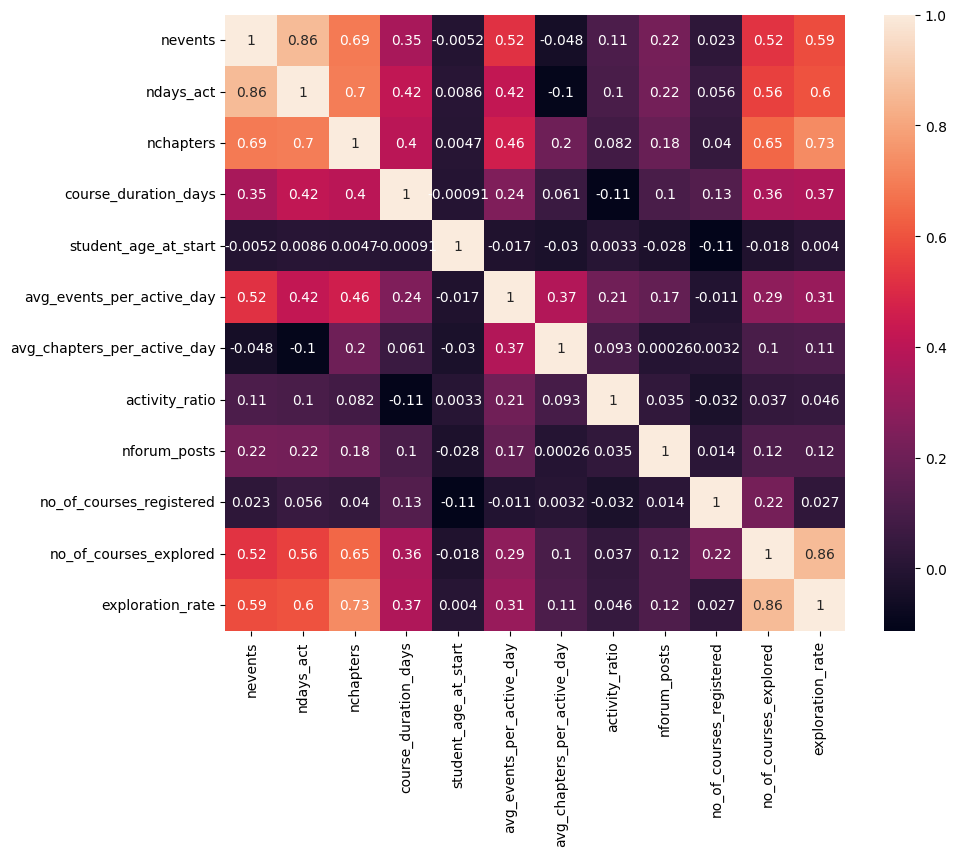

In [68]:
# Earlier some columns had skewness greater than 20, now the skewness has reduced greatly. We will treat this further if needed.

# Now plotting the correlation heatmap of the numerical columns

plt.figure(figsize = (10, 8))
sns.heatmap(X_train_EDA[num_cols].corr(), annot=True)
plt.show()

In [69]:
# The exploration_rate column is highly correlated with the no_of_courses_explored. So, one of these has to be removed.
# Also, the ndays_act and nevents are highly correlated. We have to remove one of these while building logistic regression model.
# Tree-based models can handle multicollinearity.

In [70]:
# Checking the skewness of each numerical column:

for col in num_cols:
    print(f"Skewnes of the column {col} is {skew(X_train_EDA[col])}.")

Skewnes of the column nevents is 5.226865606562527.
Skewnes of the column ndays_act is 5.502071036941655.
Skewnes of the column nchapters is 4.415372931192738.
Skewnes of the column course_duration_days is 2.428525996143217.
Skewnes of the column student_age_at_start is 1.7256883061395878.
Skewnes of the column avg_events_per_active_day is 1.227814597789104.
Skewnes of the column avg_chapters_per_active_day is 2.3092629806088807.
Skewnes of the column activity_ratio is 10.180190749955827.
Skewnes of the column nforum_posts is 9.070142886199882.
Skewnes of the column no_of_courses_registered is 1.7867774679081525.
Skewnes of the column no_of_courses_explored is 3.371397369172172.
Skewnes of the column exploration_rate is 3.6237138115827854.


In [71]:
print(len(num_cols))
print(len(cat_cols))
print(X_train_EDA.shape)

12
7
(447251, 27)


In [72]:
cat_cols

['course_id',
 'final_cc_cname_DI',
 'viewed',
 'explored',
 'start_year',
 'LoE_DI',
 'gender']

In [73]:
# ALL THE NUMERICAL COLUMNS HAVE SKEWNESS GREATER THAN 1. SO WE NEED TO TRANSFORM EACH OF THESE FEATURES
# TO REDUCE THE SKEWNESS, AS LOGISTIC REGRESSION IS SENSITIVE TO SKEWED DATA.

In [74]:
# Transforming the skewed features using yeo-johnson method.

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method = "yeo-johnson", standardize = False)
X_train_EDA[num_cols] = pt.fit_transform(X_train_EDA[num_cols])

In [75]:
# Checking the skewness again
for col in num_cols:
    print(f"Skewnes of the column {col} is {skew(X_train_EDA[col])}.")

Skewnes of the column nevents is 0.03378540821258379.
Skewnes of the column ndays_act is 0.35502359494912283.
Skewnes of the column nchapters is 0.07247065515612396.
Skewnes of the column course_duration_days is 0.01477936883951516.
Skewnes of the column student_age_at_start is -0.026160627961973524.
Skewnes of the column avg_events_per_active_day is 0.09383538681194685.
Skewnes of the column avg_chapters_per_active_day is 0.10702635753751293.
Skewnes of the column activity_ratio is 0.9844047024742593.
Skewnes of the column nforum_posts is 9.0701428861999.
Skewnes of the column no_of_courses_registered is 0.4499079471235329.
Skewnes of the column no_of_courses_explored is 2.7201888587389726.
Skewnes of the column exploration_rate is 2.7216943687588957.


In [76]:
num_cols

['nevents',
 'ndays_act',
 'nchapters',
 'course_duration_days',
 'student_age_at_start',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day',
 'activity_ratio',
 'nforum_posts',
 'no_of_courses_registered',
 'no_of_courses_explored',
 'exploration_rate']

In [77]:
features_to_transform = num_cols.copy()
features_to_transform

['nevents',
 'ndays_act',
 'nchapters',
 'course_duration_days',
 'student_age_at_start',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day',
 'activity_ratio',
 'nforum_posts',
 'no_of_courses_registered',
 'no_of_courses_explored',
 'exploration_rate']

In [78]:
features_to_scale = features_to_transform.copy()
features_to_scale.append("start_year")
features_to_scale

['nevents',
 'ndays_act',
 'nchapters',
 'course_duration_days',
 'student_age_at_start',
 'avg_events_per_active_day',
 'avg_chapters_per_active_day',
 'activity_ratio',
 'nforum_posts',
 'no_of_courses_registered',
 'no_of_courses_explored',
 'exploration_rate',
 'start_year']

In [79]:
features_to_drop = ["exploration_rate", "nevents"]

In [80]:
cols_to_freq_encode = ["course_id", "final_cc_cname_DI"]

In [81]:
cols_to_map = "LoE_DI"
cols_to_one_hot = "gender"

# For tree-based models, we can use map or label encoder for gender.

In [82]:
X_train_EDA.head()

,course_id,viewed,explored,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day,nevents_outliers,ndays_act_outliers,nchapters_outliers,course_duration_days_outliers,outliers_avg_chapters_per_active_day,outliers_nforum_posts,outliers_no_of_courses_registered,outliers_no_of_courses_explored
0,HarvardX/CB22x/2013_Spring,0,0,United States,Bachelor's,m,2.569973,0.822363,0.602469,-0.0,0.433631,-0.000000,2012,5.436143,0.024538,0.942546,-0.000000,1.452661,0.291964,0,1,0,1,0,0,1,0
1,HarvardX/CS50x/2012,1,0,United States,Bachelor's,m,2.569973,0.822363,0.466383,-0.0,0.433631,-0.000000,2012,2.414579,-0.000000,0.942546,-0.000000,1.452661,0.099163,0,1,0,0,0,0,1,0
2,HarvardX/CB22x/2013_Spring,0,0,United States,Bachelor's,m,2.569973,0.852344,0.602469,-0.0,0.440013,0.073561,2013,5.291085,0.046574,0.942546,0.046138,1.452661,0.291964,0,1,0,1,0,0,1,1
3,HarvardX/CS50x/2012,0,0,United States,Bachelor's,m,2.569973,0.852344,0.602469,-0.0,0.440013,0.073561,2012,2.414579,-0.000000,0.942546,0.046138,1.452661,0.291964,0,1,0,0,0,0,1,1
4,HarvardX/ER22x/2013_Spring,0,0,United States,Bachelor's,m,2.569973,0.852344,0.602469,-0.0,0.440013,0.073561,2012,2.414579,-0.000000,0.942546,0.046138,1.452661,0.291964,0,1,0,0,0,0,1,1


In [83]:
X_train_EDA.columns

Index(['course_id', 'viewed', 'explored', 'final_cc_cname_DI', 'LoE_DI',
       'gender', 'nevents', 'ndays_act', 'nchapters', 'nforum_posts',
       'no_of_courses_registered', 'no_of_courses_explored', 'start_year',
       'course_duration_days', 'activity_ratio', 'student_age_at_start',
       'exploration_rate', 'avg_events_per_active_day',
       'avg_chapters_per_active_day', 'nevents_outliers', 'ndays_act_outliers',
       'nchapters_outliers', 'course_duration_days_outliers',
       'outliers_avg_chapters_per_active_day', 'outliers_nforum_posts',
       'outliers_no_of_courses_registered', 'outliers_no_of_courses_explored'],
      dtype='object')

In [84]:
X_train.columns

Index(['course_id', 'viewed', 'explored', 'final_cc_cname_DI', 'LoE_DI', 'YoB',
       'gender', 'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act',
       'nchapters', 'nforum_posts', 'no_of_courses_registered',
       'no_of_courses_explored'],
      dtype='object')

In [85]:
X_train.dtypes

course_id                    object
viewed                        int64
explored                      int64
final_cc_cname_DI            object
LoE_DI                       object
YoB                         float64
gender                       object
start_time_DI                object
last_event_DI                object
nevents                     float64
ndays_act                   float64
nchapters                   float64
nforum_posts                  int64
no_of_courses_registered      int64
no_of_courses_explored        int64
dtype: object

In [86]:
X_train["course_id"].unique()

array(['HarvardX/CB22x/2013_Spring', 'HarvardX/CS50x/2012',
       'HarvardX/ER22x/2013_Spring', 'HarvardX/PH207x/2012_Fall',
       'HarvardX/PH278x/2013_Spring', 'MITx/6.002x/2012_Fall',
       'MITx/6.002x/2013_Spring', 'MITx/14.73x/2013_Spring',
       'MITx/2.01x/2013_Spring', 'MITx/3.091x/2012_Fall',
       'MITx/3.091x/2013_Spring', 'MITx/6.00x/2012_Fall',
       'MITx/7.00x/2013_Spring', 'MITx/8.02x/2013_Spring',
       'MITx/6.00x/2013_Spring', 'MITx/8.MReV/2013_Summer'], dtype=object)

In [87]:
X_train["final_cc_cname_DI"].unique()

array(['United States', 'France', 'Unknown/Other', 'Mexico', 'Australia',
       'India', 'Canada', 'Other South Asia',
       'Other North & Central Amer., Caribbean', 'Other Oceania', 'Japan',
       'Other Africa', 'Colombia', 'Russian Federation', 'Other Europe',
       'Germany', 'Other Middle East/Central Asia', 'Poland', 'Indonesia',
       'Bangladesh', 'China', 'United Kingdom', 'Spain', 'Ukraine',
       'Greece', 'Pakistan', 'Nigeria', 'Egypt', 'Other South America',
       'Brazil', 'Portugal', 'Other East Asia', 'Philippines', 'Morocco'],
      dtype=object)

In [88]:
X_train["start_time_DI"].unique()

array(['2012-12-19', '2012-10-15', '2013-02-08', '2012-09-17',
       '2013-01-01', '2013-06-17', '2013-01-24', '2013-06-27',
       '2012-07-26', '2013-07-30', '2012-10-25', '2012-10-19',
       '2013-03-03', '2012-10-24', '2012-12-20', '2012-10-29',
       '2012-10-22', '2012-12-23', '2012-09-27', '2012-12-10',
       '2013-02-20', '2012-10-13', '2013-04-22', '2013-03-16',
       '2012-07-24', '2013-02-26', '2013-02-13', '2013-01-23',
       '2012-08-17', '2013-08-06', '2012-08-16', '2012-12-21',
       '2012-09-24', '2013-05-26', '2012-12-29', '2013-06-02',
       '2013-05-27', '2013-01-06', '2012-07-30', '2013-03-21',
       '2013-06-04', '2013-04-30', '2012-09-20', '2012-12-22',
       '2013-05-01', '2013-02-07', '2013-01-07', '2012-09-02',
       '2013-02-16', '2012-10-03', '2013-03-13', '2012-12-24',
       '2012-08-20', '2012-12-25', '2012-12-28', '2012-10-18',
       '2013-01-30', '2012-07-25', '2012-07-31', '2013-02-12',
       '2012-09-10', '2013-07-13', '2012-09-01', '2013-

In [89]:
X_train["last_event_DI"].unique()

array(['2013-11-17', nan, '2013-05-23', '2013-05-14', '2013-06-17',
       '2013-08-03', '2013-08-17', '2013-01-16', '2013-08-27',
       '2012-12-04', '2013-03-03', '2013-05-18', '2013-03-04',
       '2013-03-30', '2013-03-31', '2013-02-27', '2013-06-29',
       '2013-03-18', '2013-05-20', '2013-03-14', '2013-04-23',
       '2013-03-16', '2013-02-26', '2013-02-14', '2013-03-20',
       '2012-08-16', '2013-03-29', '2013-03-23', '2013-05-26',
       '2013-02-12', '2013-04-30', '2013-06-02', '2013-06-01',
       '2013-07-30', '2013-03-17', '2013-07-02', '2013-05-28',
       '2012-08-28', '2013-05-01', '2013-06-30', '2013-05-13',
       '2012-11-07', '2013-05-24', '2013-04-01', '2013-05-15',
       '2013-02-13', '2013-02-16', '2013-07-29', '2013-03-13',
       '2013-03-12', '2013-04-02', '2012-08-17', '2013-06-23',
       '2013-07-21', '2012-07-25', '2013-06-11', '2013-06-21',
       '2013-02-21', '2013-07-13', '2012-09-01', '2013-04-04',
       '2013-06-07', '2013-07-24', '2012-10-15', '

In [90]:
X_train["LoE_DI"].unique()

array([nan, 'Secondary', "Master's", "Bachelor's", 'Doctorate',
       'Less than Secondary'], dtype=object)

In [91]:
X_train["gender"].unique()

array([nan, 'm', 'f', 'o'], dtype=object)

In [92]:
df[df["certified"]== 1]

,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,gender,nevents,ndays_act,nchapters,nforum_posts,no_of_courses_registered,no_of_courses_explored,start_year,course_duration_days,activity_ratio,student_age_at_start,exploration_rate,avg_events_per_active_day,avg_chapters_per_active_day
118,HarvardX/CS50x/2012,MHxPC130180765,1,1,1,India,NaN,NaN,439.0,47.0,11.0,0,3,2,2012,206.0,0.228155,NaN,0.666667,9.340426,0.234043
137,HarvardX/ER22x/2013_Spring,MHxPC130007191,1,1,1,Russian Federation,NaN,NaN,1735.0,44.0,34.0,0,1,1,2012,220.0,0.200000,NaN,1.000000,39.431818,0.772727
258,HarvardX/CS50x/2012,MHxPC130465525,1,1,1,Other Europe,NaN,NaN,1014.0,99.0,12.0,0,2,1,2012,333.0,0.297297,NaN,0.500000,10.242424,0.121212
291,HarvardX/PH207x/2012_Fall,MHxPC130494143,1,1,1,United States,NaN,NaN,4162.0,49.0,16.0,0,1,1,2012,157.0,0.312102,NaN,1.000000,84.938776,0.326531
341,HarvardX/CS50x/2012,MHxPC130503548,1,1,1,United Kingdom,NaN,NaN,311.0,38.0,12.0,0,1,1,2012,329.0,0.115502,NaN,1.000000,8.184211,0.315789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627768,MITx/8.MReV/2013_Summer,MHxPC130141567,1,1,1,Indonesia,Secondary,f,10099.0,55.0,40.0,0,1,1,2013,78.0,0.705128,16.0,1.000000,183.618182,0.727273
627778,MITx/8.MReV/2013_Summer,MHxPC130016604,1,0,1,Other South Asia,Secondary,m,2998.0,14.0,24.0,0,1,0,2013,43.0,0.325581,17.0,0.000000,214.142857,1.714286
627822,MITx/8.MReV/2013_Summer,MHxPC130175757,1,1,1,India,Secondary,m,11091.0,33.0,43.0,0,1,1,2013,74.0,0.445946,21.0,1.000000,336.090909,1.303030
628278,MITx/8.MReV/2013_Summer,MHxPC130418138,1,1,1,India,Less than Secondary,f,3012.0,12.0,27.0,0,1,1,2013,56.0,0.214286,16.0,1.000000,251.000000,2.250000


In [93]:
X_train_EDA["nevents"].max()

np.float64(4.963442063133942)